In [50]:
import torch

if torch.cuda.is_available():
    device = "cuda"
    print("✅ GPU found:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("⚠️ No GPU detected!")
    print("👉 Fix: Runtime menu → Change Runtime Type → T4 GPU → Save")

print(f"We'll train on: {device}")

✅ GPU found: Tesla T4
We'll train on: cuda


In [51]:
# First, let's import tools we need
# 're' = regular expressions = a tool for searching/cleaning text
# 'json' = a tool for saving/loading data
import re
import json
from collections import Counter
# Counter is a special dictionary that COUNTS things
# Example: Counter(["a","b","a"]) → {"a":2, "b":1}

# ============================================================
# STEP 1: The Tokenizer CLASS
# ============================================================
# A CLASS is like a blueprint.
# Just like a blueprint for a house isn't a house —
# a class isn't the tokenizer yet. It's the PLAN for one.
# We'll BUILD one from this blueprint later.

class TinyClaudeTokenizer:

    # __init__ runs automatically when we CREATE a tokenizer
    # It's like the "setup" function
    def __init__(self):

        # These are dictionaries (like two-way lookup tables)
        self.word_to_id = {}   # word  → number  (for encoding)
        self.id_to_word = {}   # number → word   (for decoding)

        # Special tokens — every language model needs these
        # They're like punctuation marks for the AI
        self.special_tokens = {
            "<PAD>": 0,    # PAD = padding (filling blank space)
            "<UNK>": 1,    # UNK = unknown word we've never seen
            "<BOS>": 2,    # BOS = Beginning Of Sentence
            "<EOS>": 3,    # EOS = End Of Sentence
            "<THINK>": 4,  # THINK = start of reasoning (our special sauce! 🧠)
            "</THINK>": 5, # /THINK = end of reasoning
        }

        # Load special tokens into our lookup table
        for token, idx in self.special_tokens.items():
            self.word_to_id[token] = idx
            self.id_to_word[idx] = token

        self.vocab_size = len(self.special_tokens)  # starts at 6

    # ============================================================
    # STEP 2: Clean text before processing
    # ============================================================
    def clean_text(self, text):
        text = text.lower()              # "Hello" → "hello"
        text = re.sub(r'[^a-z0-9\s\?\!\.\,]', '', text)  # remove weird symbols
        text = re.sub(r'\s+', ' ', text) # remove extra spaces
        return text.strip()              # remove spaces at start/end

    # ============================================================
    # STEP 3: Split text into tokens (just words for now)
    # ============================================================
    def tokenize(self, text):
        text = self.clean_text(text)
        return text.split()   # "hello world" → ["hello", "world"]

    # ============================================================
    # STEP 4: BUILD vocabulary from a list of texts
    # ============================================================
    def build_vocab(self, texts, max_vocab=5000):
        print("📚 Building vocabulary...")

        # Count every word across all texts
        word_counts = Counter()

        for text in texts:                    # loop through each text
            tokens = self.tokenize(text)      # split into words
            word_counts.update(tokens)        # count them

        print(f"   Found {len(word_counts):,} unique words in training data")

        # Keep only the most common words (up to max_vocab)
        # Real language has millions of words — we only need the common ones
        most_common = word_counts.most_common(max_vocab - len(self.special_tokens))

        # Add them to our lookup tables
        for word, count in most_common:
            if word not in self.word_to_id:        # don't add duplicates
                idx = self.vocab_size              # assign next available number
                self.word_to_id[word] = idx
                self.id_to_word[idx] = word
                self.vocab_size += 1

        print(f"   ✅ Vocabulary built! Size: {self.vocab_size:,} tokens")

    # ============================================================
    # STEP 5: Encode — convert words to numbers
    # ============================================================
    def encode(self, text, add_special_tokens=True):
        tokens = self.tokenize(text)

        # Convert each word to its ID number
        # If word is unknown → use <UNK> token (id=1)
        ids = [self.word_to_id.get(token, 1) for token in tokens]

        if add_special_tokens:
            ids = [2] + ids + [3]   # wrap with <BOS>=2 and <EOS>=3

        return ids

    # ============================================================
    # STEP 6: Decode — convert numbers back to words
    # ============================================================
    def decode(self, ids):
        words = []
        for id in ids:
            word = self.id_to_word.get(id, "<UNK>")
            # Skip special tokens when showing output
            if word not in ["<PAD>", "<BOS>", "<EOS>"]:
                words.append(word)
        return " ".join(words)

print("✅ Tokenizer class defined!")
print("💡 We just created a BLUEPRINT. Next we'll build one and test it.")

✅ Tokenizer class defined!
💡 We just created a BLUEPRINT. Next we'll build one and test it.


In [52]:
# Let's CREATE a tokenizer from our blueprint
# This is called "instantiating" a class
tokenizer = TinyClaudeTokenizer()

# Give it some sample sentences to learn from
# (Later we'll use real training data — for now just testing)
sample_texts = [
    "hello how are you today",
    "what is the meaning of life",
    "i am a small language model",
    "i can think and reason about questions",
    "the sky is blue and the grass is green",
    "how does artificial intelligence work",
    "can you help me understand this problem",
    "i will think carefully before answering",
]

# Build vocabulary from these sentences
tokenizer.build_vocab(sample_texts)

# ---- TEST 1: Encode a sentence ----
test_sentence = "hello how are you"
encoded = tokenizer.encode(test_sentence)
print(f"\n📝 Original : '{test_sentence}'")
print(f"🔢 Encoded  : {encoded}")

# ---- TEST 2: Decode it back ----
decoded = tokenizer.decode(encoded)
print(f"📝 Decoded  : '{decoded}'")

# ---- TEST 3: Unknown word ----
unknown_test = tokenizer.encode("hello galaxy brain")
print(f"\n🔍 'hello galaxy brain' encodes to: {unknown_test}")
print(f"   ('galaxy' and 'brain' are unknown → become 1 = <UNK>)")

# ---- TEST 4: See our special tokens ----
print(f"\n⭐ Special tokens:")
for token, idx in tokenizer.special_tokens.items():
    print(f"   {token:10} → {idx}")

📚 Building vocabulary...
   Found 40 unique words in training data
   ✅ Vocabulary built! Size: 46 tokens

📝 Original : 'hello how are you'
🔢 Encoded  : [2, 14, 9, 15, 10, 3]
📝 Decoded  : 'hello how are you'

🔍 'hello galaxy brain' encodes to: [2, 14, 1, 1, 3]
   ('galaxy' and 'brain' are unknown → become 1 = <UNK>)

⭐ Special tokens:
   <PAD>      → 0
   <UNK>      → 1
   <BOS>      → 2
   <EOS>      → 3
   <THINK>    → 4
   </THINK>   → 5


In [53]:
import torch
import torch.nn as nn

class TinyClaudeEmbedding(nn.Module):

    def __init__(self, vocab_size, embed_dim, max_seq_len):
        super().__init__()

        # -----------------------------------------------
        # WORD EMBEDDINGS
        # -----------------------------------------------
        # nn.Embedding = a lookup table (like a dictionary but with math)
        # Shape: [vocab_size x embed_dim] = [5000 x 128]
        # Each word ID maps to a row of 128 numbers
        # These 128 numbers are LEARNED during training!
        self.word_embeddings = nn.Embedding(vocab_size, embed_dim)

        # -----------------------------------------------
        # POSITION EMBEDDINGS
        # -----------------------------------------------
        # Here's a problem: after tokenizing, word ORDER is lost!
        # [2, 6, 7, 8, 3] — the model just sees numbers
        # It doesn't know word 6 came BEFORE word 7
        #
        # Solution: add a second embedding for POSITION
        # Word at position 0 gets a position vector added to it
        # Word at position 1 gets a different position vector
        # Now the model knows word order! 🎉
        self.position_embeddings = nn.Embedding(max_seq_len, embed_dim)

        # Dropout = randomly zero out 10% of values during training
        # Why? Forces the model to not rely on any single number
        # Makes it more robust — like studying without notes!
        self.dropout = nn.Dropout(0.1)

        self.embed_dim = embed_dim

    def forward(self, token_ids):
        # token_ids shape: [batch_size, sequence_length]
        # Example: [[2,6,7,8,3], [2,9,10,3,0]] ← 2 sentences

        batch_size, seq_len = token_ids.shape

        # STEP 1: Get word embeddings
        # Each token ID → row in embedding table → 128 numbers
        word_emb = self.word_embeddings(token_ids)
        # Shape: [batch_size, seq_len, embed_dim]
        # Example: [2, 5, 128] ← 2 sentences, 5 tokens each, 128 numbers

        # STEP 2: Create position indices [0, 1, 2, 3, 4, ...]
        positions = torch.arange(seq_len, device=token_ids.device)
        # arange = "array range" = like Python's range() but as tensor
        # Result: tensor([0, 1, 2, 3, 4])

        # Expand positions for the whole batch
        positions = positions.unsqueeze(0).expand(batch_size, -1)
        # unsqueeze(0) adds a dimension: [5] → [1, 5]
        # expand copies it for each sentence: [1, 5] → [2, 5]

        # STEP 3: Get position embeddings
        pos_emb = self.position_embeddings(positions)
        # Shape: [batch_size, seq_len, embed_dim]

        # STEP 4: ADD word + position embeddings together
        # Now each token vector contains BOTH its meaning AND its position!
        embeddings = word_emb + pos_emb

        # STEP 5: Apply dropout
        embeddings = self.dropout(embeddings)

        return embeddings

print("✅ Embedding layer defined!")

✅ Embedding layer defined!


In [54]:
# Hyperparameters (defined here for demonstration, ideally in a separate config cell)
VOCAB_SIZE  = 5000
EMBED_DIM   = 128
MAX_SEQ_LEN = 256
NUM_HEADS   = 4
FF_DIM      = 512
DROPOUT     = 0.1

# Create our embedding layer using our hyperparameters from Cell 3
embedding_layer = TinyClaudeEmbedding(
    vocab_size  = VOCAB_SIZE,    # 5000
    embed_dim   = EMBED_DIM,     # 128
    max_seq_len = MAX_SEQ_LEN    # 256
)

# Simulate a batch of 2 sentences, each with 5 tokens
# (pretend these are encoded sentences from our tokenizer)
fake_tokens = torch.tensor(
    [[2, 6, 7, 8, 3],    # sentence 1: <BOS> hello how are <EOS>
    [2, 9, 10, 11, 3],  # sentence 2: <BOS> what is life <EOS>
])

# Pass through embedding layer
output = embedding_layer(fake_tokens)

# --- Understand the shapes ---
print("📐 Shape breakdown:")
print(f"   Input  shape: {fake_tokens.shape}")
print(f"   → {fake_tokens.shape[0]} sentences")
print(f"   → {fake_tokens.shape[1]} tokens per sentence")
print(f"   Output shape: {output.shape}")
print(f"   → {output.shape[0]} sentences")
print(f"   → {output.shape[1]} tokens per sentence")
print(f"   → {output.shape[2]} numbers per token (meaning vector)")

# --- Look at one word's embedding ---
print(f"\n🔍 First token of first sentence (token id=2, which is <BOS>):")
print(f"   First 8 numbers: {output[0][0][:8].tolist()}")
print(f"   (These 128 numbers represent its meaning + position)")

# --- Count parameters ---
total_params = sum(p.numel() for p in embedding_layer.parameters())
print(f"\n📊 Embedding layer has {total_params:,} learnable parameters")
print(f"   Word embeddings : {VOCAB_SIZE * EMBED_DIM:,}")
print(f"   Pos  embeddings : {MAX_SEQ_LEN * EMBED_DIM:,}")
print(f"   All randomly initialized — training will tune them!")


📐 Shape breakdown:
   Input  shape: torch.Size([2, 5])
   → 2 sentences
   → 5 tokens per sentence
   Output shape: torch.Size([2, 5, 128])
   → 2 sentences
   → 5 tokens per sentence
   → 128 numbers per token (meaning vector)

🔍 First token of first sentence (token id=2, which is <BOS>):
   First 8 numbers: [1.6134288311004639, 0.13182857632637024, 1.152191162109375, -0.7314258217811584, -1.4769189357757568, 0.6473226547241211, 0.7234469056129456, 2.086367130279541]
   (These 128 numbers represent its meaning + position)

📊 Embedding layer has 672,768 learnable parameters
   Word embeddings : 640,000
   Pos  embeddings : 32,768
   All randomly initialized — training will tune them!


In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class TinyClaudeAttention(nn.Module):

    def __init__(self, embed_dim, num_heads):
        super().__init__()

        # Safety check — embed_dim must divide evenly into heads
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim  = embed_dim            # 128
        self.num_heads  = num_heads            # 4
        self.head_dim   = embed_dim // num_heads  # 128 ÷ 4 = 32 per head
        # '//' = integer division (no decimals): 128 // 4 = 32

        # -----------------------------------------------
        # THREE LINEAR LAYERS — create Q, K, V
        # -----------------------------------------------
        # nn.Linear = a learnable math transformation
        # It takes a vector of size A and outputs size B
        # Think of it like a translator: 128 numbers → 128 numbers
        # but LEARNED — it figures out the best translation!

        self.query = nn.Linear(embed_dim, embed_dim)  # makes Q
        self.key   = nn.Linear(embed_dim, embed_dim)  # makes K
        self.value = nn.Linear(embed_dim, embed_dim)  # makes V

        # Output projection — combines all heads back together
        self.output_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        # x shape: [batch_size, seq_len, embed_dim]
        #           [2,          5,       128]

        batch_size, seq_len, embed_dim = x.shape
        # Python lets you unpack multiple values at once!
        # Instead of: batch_size = x.shape[0]
        #             seq_len    = x.shape[1]  etc.

        # -----------------------------------------------
        # STEP 1: Create Q, K, V from input
        # -----------------------------------------------
        Q = self.query(x)  # [batch, seq_len, embed_dim]
        K = self.key(x)    # [batch, seq_len, embed_dim]
        V = self.value(x)  # [batch, seq_len, embed_dim]

        # -----------------------------------------------
        # STEP 2: Split into multiple heads
        # -----------------------------------------------
        # Reshape: [batch, seq, 128] → [batch, seq, 4, 32]
        # Then swap to: [batch, 4, seq, 32]
        # So each head works on its own 32-number slice

        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        Q = Q.transpose(1, 2)  # [batch, heads, seq, head_dim]

        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = K.transpose(1, 2)

        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = V.transpose(1, 2)

        # -----------------------------------------------
        # STEP 3: Calculate attention scores
        # -----------------------------------------------
        # For every word, compare its Q against every word's K
        # Higher score = more attention = more influence

        # K.transpose(-2,-1) flips the last two dimensions
        # matmul then does: [batch, heads, seq, 32] x [batch, heads, 32, seq]
        #                 = [batch, heads, seq, seq]  ← attention matrix!

        scores = torch.matmul(Q, K.transpose(-2, -1))

        # Scale down by sqrt(head_dim) — prevents scores from being too large
        # Large scores → softmax becomes too sharp → poor learning
        # This trick was in the original "Attention is All You Need" paper!
        scores = scores / math.sqrt(self.head_dim)

        # -----------------------------------------------
        # STEP 4: Apply CAUSAL MASK (this makes it a decoder!)
        # -----------------------------------------------
        # Our model should only look at PAST words, not future ones!
        # When predicting word 3, it can't cheat by seeing word 4, 5...
        # We mask future positions with -infinity so softmax ignores them

        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device),
            diagonal=1
        ).bool()
        # triu = upper triangle of a matrix
        # For seq_len=4, looks like:
        # [[False, True,  True,  True ],   ← word 0 can't see 1,2,3
        #  [False, False, True,  True ],   ← word 1 can't see 2,3
        #  [False, False, False, True ],   ← word 2 can't see 3
        #  [False, False, False, False]]   ← word 3 can see all past

        scores = scores.masked_fill(causal_mask, float('-inf'))
        # -infinity → after softmax becomes 0 → zero attention!

        # -----------------------------------------------
        # STEP 5: Softmax → attention weights (probabilities)
        # -----------------------------------------------
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        # -----------------------------------------------
        # STEP 6: Multiply weights by Values
        # -----------------------------------------------
        # High attention weight × Value = that word contributes more
        # Low attention weight × Value = that word contributes less

        context = torch.matmul(attention_weights, V)
        # Shape: [batch, heads, seq, head_dim]

        # -----------------------------------------------
        # STEP 7: Merge heads back together
        # -----------------------------------------------
        context = context.transpose(1, 2)  # [batch, seq, heads, head_dim]
        context = context.contiguous()     # make memory layout clean
        context = context.view(batch_size, seq_len, embed_dim)  # [batch, seq, 128]

        # -----------------------------------------------
        # STEP 8: Final output projection
        # -----------------------------------------------
        output = self.output_proj(context)

        return output, attention_weights

print("✅ Attention mechanism defined!")

✅ Attention mechanism defined!


📐 Attention shapes:
   Input  : torch.Size([2, 5, 128])
   Output : torch.Size([2, 5, 128])  ← same shape! attention is a transformer
   Weights: torch.Size([2, 4, 5, 5])  ← [batch, heads, seq, seq]


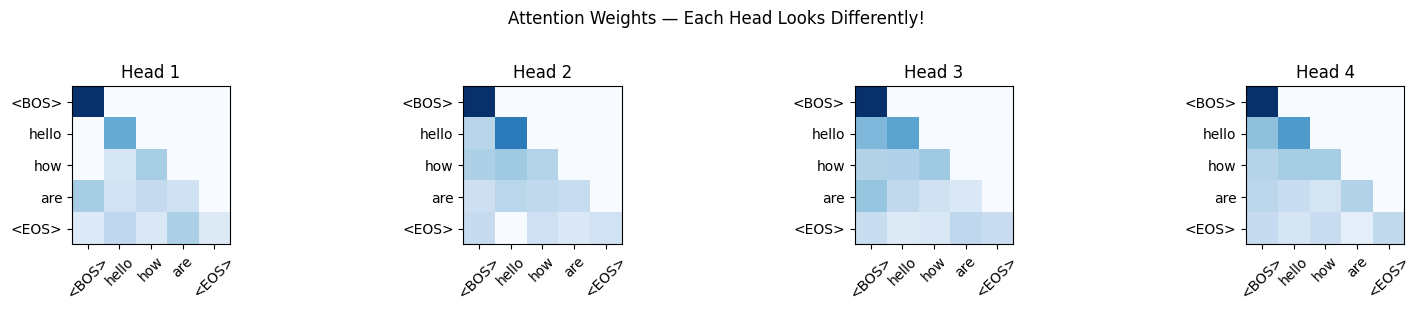


✅ Darker blue = more attention paid to that word!
✅ Notice the lower triangle pattern — causal masking at work!


In [56]:
import matplotlib.pyplot as plt

# Create attention layer
attention = TinyClaudeAttention(
    embed_dim = EMBED_DIM,    # 128
    num_heads = NUM_HEADS     # 4
)

# Use the output from our embedding layer as input
# (attention takes embeddings and figures out what to focus on)
fake_embeddings = torch.randn(2, 5, EMBED_DIM)
# randn = random numbers from normal distribution
# Shape: [2 sentences, 5 tokens, 128 dimensions]

# Run through attention
output, weights = attention(fake_embeddings)

print("📐 Attention shapes:")
print(f"   Input  : {fake_embeddings.shape}")
print(f"   Output : {output.shape}  ← same shape! attention is a transformer")
print(f"   Weights: {weights.shape}  ← [batch, heads, seq, seq]")

# --- Visualize one attention head ---
# weights[0] = first sentence
# weights[0][0] = first attention head
# This shows: for each word, how much it attends to every other word

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
tokens = ["<BOS>", "hello", "how", "are", "<EOS>"]

for head in range(4):
    ax = axes[head]
    head_weights = weights[0][head].detach().numpy()

    im = ax.imshow(head_weights, cmap='Blues')
    ax.set_title(f'Head {head+1}')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(tokens, rotation=45)
    ax.set_yticklabels(tokens)

plt.suptitle("Attention Weights — Each Head Looks Differently!", y=1.02)
plt.tight_layout()
plt.savefig('attention.png', bbox_inches='tight')
plt.show()
print("\n✅ Darker blue = more attention paid to that word!")
print("✅ Notice the lower triangle pattern — causal masking at work!")


In [57]:
import torch
import torch.nn as nn

# ---- CONCEPT 1: nn.Sequential — chain layers together ----
# Instead of calling layer1, layer2, layer3 separately...
# Sequential does it automatically in order!

model = nn.Sequential(
    nn.Linear(128, 512),   # step 1: expand
    nn.ReLU(),             # step 2: activation
    nn.Linear(512, 128),   # step 3: compress back
)

x = torch.randn(2, 5, 128)
output = model(x)   # runs all 3 steps automatically!
print(output.shape) # torch.Size([2, 5, 128])

# ---- CONCEPT 2: nn.LayerNorm — stabilizing numbers ----
# During training numbers can explode (999999) or vanish (0.000001)
# LayerNorm keeps them in a healthy range
# Like a volume knob that auto-adjusts to prevent distortion

norm = nn.LayerNorm(128)
x = torch.randn(2, 5, 128) * 1000  # huge numbers!
x_normed = norm(x)
print(f"Before norm: mean={x.mean():.1f}, std={x.std():.1f}")
print(f"After  norm: mean={x_normed.mean():.4f}, std={x_normed.std():.4f}")
# After norm: mean≈0, std≈1  ← nice and stable!

# ---- CONCEPT 3: ReLU activation — the "thinking" switch ----
# ReLU = Rectified Linear Unit (fancy name, simple idea)
# If number > 0: keep it
# If number < 0: set to 0
# This adds non-linearity — lets model learn complex patterns

relu = nn.ReLU()
x = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])
print(relu(x))
# tensor([0., 0., 0., 1., 3.])  ← negatives become 0!

# ---- CONCEPT 4: Residual connections (skip connections) ----
# This is GENIUS and was a breakthrough in AI research
# Instead of: output = layer(input)
# We do:      output = layer(input) + input  ← add original input back!
#
# Why? Imagine you're learning and you FORGET everything.
# Residual connections = always keeping your original notes!
# The layer only needs to learn what to ADD, not everything from scratch.

x = torch.randn(2, 5, 128)
layer = nn.Linear(128, 128)
output_without_residual = layer(x)
output_with_residual    = layer(x) + x   # ← skip connection!
print("With residual, gradient can always flow back through the + path")

torch.Size([2, 5, 128])
Before norm: mean=6.9, std=1000.9
After  norm: mean=0.0000, std=1.0004
tensor([0., 0., 0., 1., 3.])
With residual, gradient can always flow back through the + path


In [58]:
class TinyClaudeBlock(nn.Module):

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()

        # -----------------------------------------------
        # PART 1: Multi-Head Attention (we built this!)
        # -----------------------------------------------
        self.attention = TinyClaudeAttention(embed_dim, num_heads)

        # -----------------------------------------------
        # PART 2: Feed Forward Network
        # -----------------------------------------------
        # This is the "private thinking" part
        # Each word independently processes what attention told it
        #
        # Structure: expand big → activate → compress back
        # 128 → 512 → 128
        # Why expand? More room to think!
        # The middle layer (512) is where complex reasoning happens

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),   # 128 → 512 (expand)
            nn.GELU(),                       # activation (smoother than ReLU)
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),   # 512 → 128 (compress)
            nn.Dropout(dropout),
        )
        # GELU = Gaussian Error Linear Unit
        # Like ReLU but smoother — works better for language models
        # Used in real GPT and Claude!

        # -----------------------------------------------
        # PART 3: Layer Normalization (applied twice)
        # -----------------------------------------------
        self.norm1 = nn.LayerNorm(embed_dim)  # after attention
        self.norm2 = nn.LayerNorm(embed_dim)  # after feed forward

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # -----------------------------------------------
        # FLOW: attention → add & norm → ff → add & norm
        # -----------------------------------------------

        # STEP 1: Attention with residual connection
        # "Pre-norm" style — normalize BEFORE attention (modern approach)
        attention_out, weights = self.attention(self.norm1(x))
        x = x + self.dropout(attention_out)
        # ↑ residual connection: add original x back in!

        # STEP 2: Feed forward with residual connection
        ff_out = self.feed_forward(self.norm2(x))
        x = x + ff_out
        # ↑ residual connection again!

        return x

print("✅ Transformer Block defined!")
print()
print("One block does:")
print("  1. Words talk to each other    (attention)")
print("  2. Stabilize                   (norm1)")
print("  3. Each word thinks privately  (feed_forward)")
print("  4. Stabilize                   (norm2)")
print("  5. Remember where we started   (residual connections x2)")

✅ Transformer Block defined!

One block does:
  1. Words talk to each other    (attention)
  2. Stabilize                   (norm1)
  3. Each word thinks privately  (feed_forward)
  4. Stabilize                   (norm2)
  5. Remember where we started   (residual connections x2)


In [59]:
# Define the missing hyperparameter
NUM_LAYERS = 4

# Create one transformer block
block = TinyClaudeBlock(
    embed_dim = EMBED_DIM,   # 128
    num_heads = NUM_HEADS,   # 4
    ff_dim    = FF_DIM,      # 512
    dropout   = DROPOUT      # 0.1
)

# Test with fake embeddings
fake_input = torch.randn(2, 5, EMBED_DIM)
block_output = block(fake_input)

print("   Shape breakdown:")
print(f"   Input : {fake_input.shape}")
print(f"   Output: {block_output.shape}  ← same shape in, same shape out!")

# Count parameters in ONE block
block_params = sum(p.numel() for p in block.parameters())
print(f"\n   One block has: {block_params:,} parameters")
print(f"   We'll stack {NUM_LAYERS} of these = {block_params * NUM_LAYERS:,} params")
print(f"\n   Each block sees language a little differently:")
print(f"   Block 1 → learns basic patterns (word order, grammar)")
print(f"   Block 2 → learns phrases and chunks")
print(f"   Block 3 → learns sentence meaning")
print(f"   Block 4 → learns reasoning and context")

   Shape breakdown:
   Input : torch.Size([2, 5, 128])
   Output: torch.Size([2, 5, 128])  ← same shape in, same shape out!

   One block has: 198,272 parameters
   We'll stack 4 of these = 793,088 params

   Each block sees language a little differently:
   Block 1 → learns basic patterns (word order, grammar)
   Block 2 → learns phrases and chunks
   Block 3 → learns sentence meaning
   Block 4 → learns reasoning and context


In [60]:
class TinyClaude(nn.Module):

    def __init__(self, vocab_size, embed_dim, num_heads,
                 num_layers, ff_dim, max_seq_len, dropout=0.1):
        super().__init__()

        # -----------------------------------------------
        # LAYER 1: Embeddings (words → vectors)
        # -----------------------------------------------
        self.embedding = TinyClaudeEmbedding(
            vocab_size, embed_dim, max_seq_len
        )

        # -----------------------------------------------
        # LAYER 2: Stack of Transformer Blocks
        # -----------------------------------------------
        # nn.ModuleList = a list of layers PyTorch can track
        # Like a regular Python list but PyTorch knows about each layer
        self.blocks = nn.ModuleList([
            TinyClaudeBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)   # create num_layers blocks
            # '_' = throwaway variable (we don't need the loop index)
        ])

        # -----------------------------------------------
        # LAYER 3: Final Normalization
        # -----------------------------------------------
        self.final_norm = nn.LayerNorm(embed_dim)

        # -----------------------------------------------
        # LAYER 4: Output Head (vectors → word predictions)
        # -----------------------------------------------
        # This is the opposite of embedding!
        # Takes 128 numbers → predicts probability of each vocab word
        # Shape: 128 → 5000 (one score per possible next word)
        self.output_head = nn.Linear(embed_dim, vocab_size)

        # -----------------------------------------------
        # WEIGHT TYING (pro trick!)
        # -----------------------------------------------
        # The embedding table and output head are related:
        # embedding: word_id → vector
        # output:    vector  → word_id
        # So we share their weights! Saves params + trains better
        self.output_head.weight = self.embedding.word_embeddings.weight

        # Initialize weights properly
        self.apply(self._init_weights)
        print(f"✅ TinyClaude initialized!")

    def _init_weights(self, module):
        # Good initialization = faster, more stable training
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, token_ids):
        # -----------------------------------------------
        # THE FULL FORWARD PASS — data flows through everything
        # -----------------------------------------------

        # Step 1: tokens → embeddings
        x = self.embedding(token_ids)
        # [batch, seq_len] → [batch, seq_len, embed_dim]

        # Step 2: through each transformer block
        for block in self.blocks:
            x = block(x)
        # Each block refines understanding deeper

        # Step 3: normalize
        x = self.final_norm(x)

        # Step 4: project to vocabulary
        logits = self.output_head(x)
        # [batch, seq_len, embed_dim] → [batch, seq_len, vocab_size]
        # 'logits' = raw scores (not probabilities yet)
        # Highest score = model's best guess for next word

        return logits

print("✅ Full TinyClaude class defined!")

✅ Full TinyClaude class defined!


In [61]:
# BUILD IT! 🚀
model = TinyClaude(
    vocab_size  = VOCAB_SIZE,    # 5000
    embed_dim   = EMBED_DIM,     # 128
    num_heads   = NUM_HEADS,     # 4
    num_layers  = NUM_LAYERS,    # 4
    ff_dim      = FF_DIM,        # 512
    max_seq_len = MAX_SEQ_LEN,   # 256
    dropout     = DROPOUT        # 0.1
)

# Move to GPU!
model = model.to(device)

# Count ALL parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n🧠 TinyClaude Model Summary:")
print(f"{'='*40}")
print(f"  Embedding layer : {VOCAB_SIZE * EMBED_DIM:>10,} params")
print(f"  Transformer x{NUM_LAYERS}  : {NUM_LAYERS * sum(p.numel() for p in TinyClaudeBlock(EMBED_DIM,NUM_HEADS,FF_DIM).parameters()):>10,} params")
print(f"  Output head     :      tied  (shared with embedding)")
print(f"{'='*40}")
print(f"  TOTAL PARAMS    : {total_params:>10,}")
print(f"  TRAINABLE       : {trainable:>10,}")
print(f"{'='*40}")
print(f"\n📊 For reference:")
print(f"  GPT-2 Small  :  117,000,000 params")
print(f"  Our model    :  {total_params:>10,} params")
print(f"  Real Claude  : billions of params")

# Test a forward pass!
fake_input  = torch.randint(0, VOCAB_SIZE, (2, 10)).to(device)
fake_output = model(fake_input)
print(f"\n✅ Forward pass works!")
print(f"   Input  shape: {fake_input.shape}  ← [2 sentences, 10 tokens]")
print(f"   Output shape: {fake_output.shape} ← [2 sentences, 10 tokens, 5000 word scores]")
print(f"\n🎉 TinyClaude is ALIVE! Now we need to feed it data and train it!")

✅ TinyClaude initialized!

🧠 TinyClaude Model Summary:
  Embedding layer :    640,000 params
  Transformer x4  :    793,088 params
  Output head     :      tied  (shared with embedding)
  TOTAL PARAMS    :  1,471,112
  TRAINABLE       :  1,471,112

📊 For reference:
  GPT-2 Small  :  117,000,000 params
  Our model    :   1,471,112 params
  Real Claude  : billions of params

✅ Forward pass works!
   Input  shape: torch.Size([2, 10])  ← [2 sentences, 10 tokens]
   Output shape: torch.Size([2, 10, 5000]) ← [2 sentences, 10 tokens, 5000 word scores]

🎉 TinyClaude is ALIVE! Now we need to feed it data and train it!


In [62]:
# Our reasoning training data
# Format: question → <THINK> reasoning </THINK> → answer
# This teaches TinyClaude to reason before answering!

training_conversations = [
    # Math reasoning
    "what is 2 plus 2 <THINK> the user wants basic addition 2 plus 2 equals 4 </THINK> the answer is 4",
    "what is 10 minus 3 <THINK> the user wants subtraction 10 minus 3 equals 7 </THINK> the answer is 7",
    "what is 3 times 4 <THINK> the user wants multiplication 3 times 4 equals 12 </THINK> the answer is 12",
    "what is 8 divided by 2 <THINK> the user wants division 8 divided by 2 equals 4 </THINK> the answer is 4",
    "what is 5 plus 7 <THINK> the user wants addition 5 plus 7 equals 12 </THINK> the answer is 12",

    # Science reasoning
    "why is the sky blue <THINK> the sky appears blue because of rayleigh scattering sunlight hits the atmosphere blue light scatters more than other colors </THINK> the sky is blue because sunlight scatters in the atmosphere and blue light scatters most",
    "what is water made of <THINK> water is a molecule consisting of hydrogen and oxygen the formula is h2o meaning 2 hydrogen atoms and 1 oxygen atom </THINK> water is made of hydrogen and oxygen its formula is h2o",
    "why do things fall down <THINK> objects fall because of gravity which is a force that pulls objects toward the center of the earth isaac newton described this </THINK> things fall because of gravity a force that pulls objects toward earth",
    "what is the sun <THINK> the sun is a star at the center of our solar system it is a giant ball of hot plasma that produces energy through nuclear fusion </THINK> the sun is a star a giant ball of hot gas that produces energy through nuclear fusion",
    "how do plants make food <THINK> plants use photosynthesis they take in sunlight water and carbon dioxide and convert them into glucose and oxygen </THINK> plants make food through photosynthesis using sunlight water and carbon dioxide",

    # Logic reasoning
    "if all dogs are animals and rex is a dog what is rex <THINK> this is a logical syllogism all dogs are animals rex is a dog therefore rex must be an animal </THINK> rex is an animal because all dogs are animals and rex is a dog",
    "what comes after monday <THINK> the days of the week in order are monday tuesday wednesday thursday friday saturday sunday so after monday comes tuesday </THINK> tuesday comes after monday",
    "if it is raining should i take an umbrella <THINK> rain makes you wet an umbrella protects you from rain so if it is raining taking an umbrella is logical </THINK> yes you should take an umbrella to stay dry",
    "what is bigger the sun or the earth <THINK> the sun is a star and much larger than earth the sun is about 109 times the diameter of earth </THINK> the sun is much bigger than earth about 109 times larger",

    # General knowledge
    "what is the capital of france <THINK> france is a country in europe its capital and largest city is paris which is known for the eiffel tower </THINK> the capital of france is paris",
    "how many days are in a week <THINK> a week consists of 7 days monday tuesday wednesday thursday friday saturday and sunday </THINK> there are 7 days in a week",
    "what language do people speak in spain <THINK> spain is a country in europe the official language is spanish also known as castilian </THINK> people in spain speak spanish",
    "what is the largest planet <THINK> in our solar system the planets are mercury venus earth mars jupiter saturn uranus neptune jupiter is by far the largest </THINK> jupiter is the largest planet in our solar system",
    "who wrote romeo and juliet <THINK> romeo and juliet is a famous tragedy it was written by william shakespeare the english playwright in the late 1500s </THINK> romeo and juliet was written by william shakespeare",
    "what is the fastest animal <THINK> when considering land animals the cheetah is known for being the fastest it can run up to 70 miles per hour </THINK> the cheetah is the fastest land animal reaching speeds of 70 miles per hour",

    # Repeat with variations to help learning
    "can you explain why the sky is blue <THINK> this is about light scattering in the atmosphere blue light has a short wavelength and scatters more when sunlight enters the atmosphere </THINK> the sky is blue due to light scattering blue light scatters most in the atmosphere",
    "tell me about gravity <THINK> gravity is a fundamental force of nature it causes objects with mass to attract each other on earth it pulls things downward </THINK> gravity is a force that attracts objects with mass on earth it pulls things toward the ground",
    "what is photosynthesis <THINK> photosynthesis is how plants create energy they use sunlight water and carbon dioxide to produce glucose and release oxygen </THINK> photosynthesis is how plants make food using sunlight water and carbon dioxide",
    "how many hours in a day <THINK> a day is one full rotation of the earth it is divided into 24 hours each hour has 60 minutes </THINK> there are 24 hours in a day",
    "what is the color of grass <THINK> grass contains chlorophyll a pigment that absorbs red and blue light and reflects green light making it appear green </THINK> grass is green because of chlorophyll which reflects green light",
]

print(f"📚 Training examples: {len(training_conversations)}")
print(f"\nExample training sample:")
print(f"'{training_conversations[0]}'")
print(f"\nNotice the <THINK> tags — this teaches reasoning!")

📚 Training examples: 25

Example training sample:
'what is 2 plus 2 <THINK> the user wants basic addition 2 plus 2 equals 4 </THINK> the answer is 4'

Notice the <THINK> tags — this teaches reasoning!


In [63]:
from torch.utils.data import Dataset, DataLoader

# --- Hyperparameters for Training ---
BATCH_SIZE    = 32
LEARNING_RATE = 3e-4
EPOCHS        = 10

# First rebuild tokenizer with our training data
tokenizer = TinyClaudeTokenizer()
tokenizer.build_vocab(training_conversations, max_vocab=VOCAB_SIZE)

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Special tokens: {list(tokenizer.special_tokens.keys())}")

# -----------------------------------------------
# Custom Dataset Class
# -----------------------------------------------
class TinyClaudeDataset(Dataset):

    def __init__(self, conversations, tokenizer, max_seq_len):
        self.examples = []
        self.tokenizer = tokenizer
        self.max_seq_len = max_seq_len

        print("\nℱ Tokenizing training data...")
        skipped = 0

        for text in conversations:
            # Encode the full conversation
            ids = tokenizer.encode(text, add_special_tokens=True)

            # Skip if too short (nothing to learn from)
            if len(ids) < 4:
                skipped += 1
                continue

            # Truncate if too long
            if len(ids) > max_seq_len:
                ids = ids[:max_seq_len]

            self.examples.append(ids)

        print(f"✅ Processed {len(self.examples)} examples ({skipped} skipped)")
        lengths = [len(e) for e in self.examples]
        print(f"   Shortest: {min(lengths)} tokens")
        print(f"   Longest : {max(lengths)} tokens")
        print(f"   Average : {sum(lengths)//len(lengths)} tokens")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ids = self.examples[idx]
        input_ids  = torch.tensor(ids[:-1], dtype=torch.long)
        target_ids = torch.tensor(ids[1:],  dtype=torch.long)
        return input_ids, target_ids


def collate_fn(batch):
    inputs, targets = zip(*batch)
    max_len = max(len(x) for x in inputs)
    padded_inputs  = []
    padded_targets = []

    for inp, tgt in zip(inputs, targets):
        pad_len = max_len - len(inp)
        padded_inputs.append(
            torch.cat([inp, torch.zeros(pad_len, dtype=torch.long)])
        )
        padded_targets.append(
            torch.cat([tgt, torch.full((pad_len,), -100, dtype=torch.long)])
        )

    return torch.stack(padded_inputs), torch.stack(padded_targets)


# Build dataset and dataloader
dataset = TinyClaudeDataset(training_conversations, tokenizer, MAX_SEQ_LEN)

dataloader = DataLoader(
    dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    collate_fn = collate_fn
)

print(f"\n⌦ DataLoader ready!")
print(f"   {len(dataset)} examples    batch size {BATCH_SIZE} = {len(dataloader)} batches per epoch")

📚 Building vocabulary...
   Found 261 unique words in training data
   ✅ Vocabulary built! Size: 267 tokens
Vocabulary size: 267
Special tokens: ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<THINK>', '</THINK>']

ℱ Tokenizing training data...
✅ Processed 25 examples (0 skipped)
   Shortest: 22 tokens
   Longest : 51 tokens
   Average : 37 tokens

⌦ DataLoader ready!
   25 examples    batch size 32 = 1 batches per epoch


In [64]:
import time

# -----------------------------------------------
# SETUP: optimizer and loss function
# -----------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,  # 0.0003
    weight_decay = 0.01            # slight penalty for huge weights
)

# Learning rate scheduler — reduces LR over time
# Like starting with big steps then taking smaller steps as you get closer
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max = EPOCHS
)

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)  # ignore pad tokens

# -----------------------------------------------
# TRAINING LOOP
# -----------------------------------------------
print("🚀 Starting Training!")
print("="*50)

train_losses = []   # track loss over time

for epoch in range(EPOCHS):
    model.train()   # tell model "we're training" (enables dropout)

    epoch_loss  = 0
    epoch_start = time.time()

    for batch_idx, (input_ids, target_ids) in enumerate(dataloader):

        # Move data to GPU
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)

        # ---- FORWARD PASS ----
        # Feed input through model → get predictions
        logits = model(input_ids)
        # logits shape: [batch, seq_len, vocab_size]

        # Reshape for loss calculation
        # CrossEntropyLoss wants: [batch*seq, vocab] and [batch*seq]
        logits_flat  = logits.view(-1, VOCAB_SIZE)
        targets_flat = target_ids.view(-1)

        # Calculate loss (how wrong were we?)
        loss = loss_fn(logits_flat, targets_flat)

        # ---- BACKWARD PASS ----
        optimizer.zero_grad()   # clear previous gradients
        loss.backward()         # calculate new gradients (backprop!)

        # Gradient clipping — prevents gradients from exploding
        # Like a speed limiter on learning
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()        # update all parameters!

        epoch_loss += loss.item()  # .item() converts tensor to Python number

    scheduler.step()   # reduce learning rate

    # Calculate averages
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    elapsed  = time.time() - epoch_start

    # Perplexity = another way to measure quality
    # Lower = better. Human language ≈ 50-100. Random = vocab_size = 5000
    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Perplexity: {perplexity:.1f} | "
          f"Time: {elapsed:.1f}s")

print("\n✅ Training complete!")

🚀 Starting Training!
Epoch  1/10 | Loss: 8.5217 | Perplexity: 5022.6 | Time: 0.3s
Epoch  2/10 | Loss: 8.3202 | Perplexity: 4105.9 | Time: 0.0s
Epoch  3/10 | Loss: 8.1854 | Perplexity: 3588.2 | Time: 0.0s
Epoch  4/10 | Loss: 8.0991 | Perplexity: 3291.6 | Time: 0.0s
Epoch  5/10 | Loss: 8.0351 | Perplexity: 3087.5 | Time: 0.0s
Epoch  6/10 | Loss: 7.9886 | Perplexity: 2947.2 | Time: 0.0s
Epoch  7/10 | Loss: 7.9569 | Perplexity: 2855.2 | Time: 0.0s
Epoch  8/10 | Loss: 7.9278 | Perplexity: 2773.4 | Time: 0.0s
Epoch  9/10 | Loss: 7.9087 | Perplexity: 2720.8 | Time: 0.0s
Epoch 10/10 | Loss: 7.9019 | Perplexity: 2702.5 | Time: 0.0s

✅ Training complete!


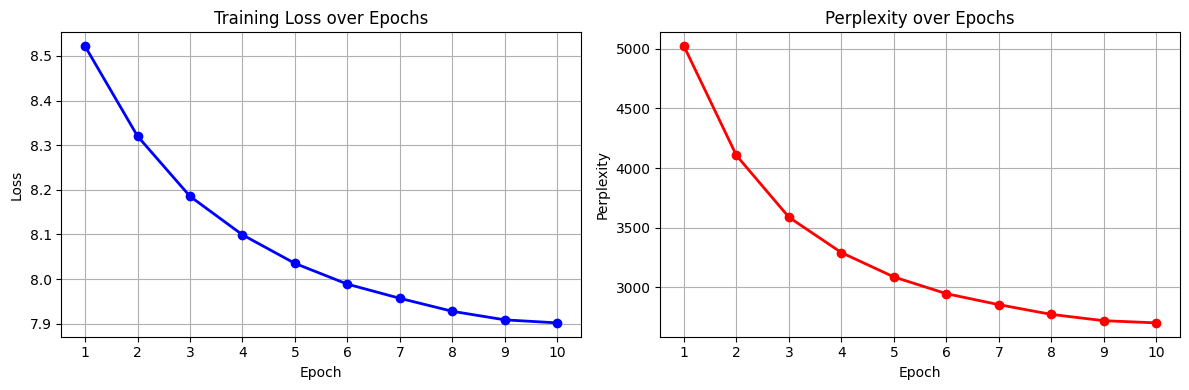

📉 Loss went from 8.5217 → 7.9019
📉 Perplexity: 5022.6 → 2702.5

💡 Lower loss = model is less surprised by training data
💡 Perplexity dropping = model is learning to predict words!


In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot 1: Loss curve
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, 'b-o', linewidth=2)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(range(1, EPOCHS+1))

# Plot 2: Perplexity curve
perplexities = [torch.exp(torch.tensor(l)).item() for l in train_losses]
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), perplexities, 'r-o', linewidth=2)
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid(True)
plt.xticks(range(1, EPOCHS+1))

plt.tight_layout()
plt.savefig('training.png', bbox_inches='tight')
plt.show()

print(f"📉 Loss went from {train_losses[0]:.4f} → {train_losses[-1]:.4f}")
print(f"📉 Perplexity: {perplexities[0]:.1f} → {perplexities[-1]:.1f}")
print(f"\n💡 Lower loss = model is less surprised by training data")
print(f"💡 Perplexity dropping = model is learning to predict words!")

In [66]:
# EXPANDED training data — 3x more examples!
extra_conversations = [
    # More math
    "what is 6 plus 6 <THINK> the user wants addition 6 plus 6 equals 12 </THINK> the answer is 12",
    "what is 9 minus 4 <THINK> the user wants subtraction 9 minus 4 equals 5 </THINK> the answer is 5",
    "what is 7 times 3 <THINK> the user wants multiplication 7 times 3 equals 21 </THINK> the answer is 21",
    "what is 20 divided by 4 <THINK> the user wants division 20 divided by 4 equals 5 </THINK> the answer is 5",
    "what is 15 plus 8 <THINK> the user wants addition 15 plus 8 equals 23 </THINK> the answer is 23",
    "what is 100 minus 37 <THINK> the user wants subtraction 100 minus 37 equals 63 </THINK> the answer is 63",

    # More science
    "what is gravity <THINK> gravity is a force that pulls objects toward each other on earth it pulls things downward toward the center </THINK> gravity is a pulling force that keeps us on the ground",
    "what is electricity <THINK> electricity is the flow of electrons through a conductor it powers our devices and lights </THINK> electricity is the flow of electrons that powers devices",
    "what is an atom <THINK> an atom is the smallest unit of matter it has a nucleus with protons and neutrons surrounded by electrons </THINK> an atom is the smallest unit of matter with a nucleus and electrons",
    "what causes rain <THINK> rain forms when water evaporates rises into the atmosphere cools and condenses into droplets that fall </THINK> rain forms when water evaporates condenses in clouds and falls as droplets",
    "what is the moon <THINK> the moon is earths natural satellite it orbits earth and reflects sunlight we see it at night </THINK> the moon is earths natural satellite that orbits us and reflects sunlight",
    "what is wind <THINK> wind is moving air it is caused by differences in air pressure warm air rises and cool air moves in </THINK> wind is moving air caused by differences in air pressure",

    # More logic
    "if today is monday what day is tomorrow <THINK> the days go monday tuesday wednesday so the day after monday is tuesday </THINK> tomorrow would be tuesday",
    "if a cat has 4 legs how many legs do 3 cats have <THINK> each cat has 4 legs 3 cats means 3 times 4 which equals 12 legs total </THINK> 3 cats have 12 legs total",
    "what is bigger an elephant or a mouse <THINK> elephants are large mammals that can weigh thousands of pounds mice are tiny rodents so elephants are much bigger </THINK> an elephant is much bigger than a mouse",
    "if you have 10 apples and eat 3 how many are left <THINK> you start with 10 apples you eat 3 so 10 minus 3 equals 7 apples remaining </THINK> you have 7 apples left",
    "what is heavier a kilogram of feathers or a kilogram of gold <THINK> both weigh exactly one kilogram so they weigh the same even though gold seems heavier </THINK> they weigh the same both are one kilogram",

    # More general knowledge
    "what is the capital of japan <THINK> japan is an island country in asia its capital and largest city is tokyo a very large modern city </THINK> the capital of japan is tokyo",
    "how many months are in a year <THINK> a year is divided into 12 months starting with january and ending with december </THINK> there are 12 months in a year",
    "what color is the sun <THINK> the sun actually emits white light but from earth it appears yellow or orange due to the atmosphere scattering blue light </THINK> the sun appears yellow from earth but actually emits white light",
    "what is the ocean <THINK> the ocean is a vast body of salt water covering most of earths surface there are five oceans pacific atlantic indian arctic and southern </THINK> the ocean is a large body of salt water covering most of earth",
    "what do bees make <THINK> bees collect nectar from flowers and convert it into honey in their hives honey is sweet and humans have eaten it for thousands of years </THINK> bees make honey from flower nectar",
    "why do we sleep <THINK> sleep is essential for the body and brain to rest and recover during sleep the brain processes memories and the body repairs itself </THINK> we sleep so our body and brain can rest recover and process memories",
    "what is a computer <THINK> a computer is an electronic device that processes information it follows instructions to perform calculations store data and run programs </THINK> a computer is an electronic device that processes information and runs programs",
    "what is the internet <THINK> the internet is a global network connecting billions of computers it allows people to share information communicate and access websites </THINK> the internet is a global network that connects computers worldwide for communication and information",

    # Repeated reasoning patterns (helps the model learn the FORMAT)
    "explain what fire is <THINK> fire is a chemical reaction called combustion when fuel combines with oxygen and heat it produces flames light and more heat </THINK> fire is a combustion reaction between fuel and oxygen that produces heat and light",
    "what makes something hot <THINK> heat is the transfer of thermal energy objects feel hot when they have more thermal energy than surrounding objects </THINK> something is hot when it has high thermal energy which transfers to cooler objects",
    "why is ice cold <THINK> ice is cold because it is frozen water at or below 0 degrees celsius it absorbs heat from surroundings making things feel cold </THINK> ice is cold because it is frozen at 0 celsius and absorbs heat from everything it touches",
    "what is a star <THINK> a star is a massive ball of hot plasma held together by gravity it produces energy through nuclear fusion in its core the sun is our nearest star </THINK> a star is a massive ball of hot gas that produces energy through nuclear fusion",
    "how do birds fly <THINK> birds fly by flapping their wings which creates lift air moves faster over the curved top of the wing creating lower pressure that lifts the bird </THINK> birds fly by flapping wings that create lift through differences in air pressure",
    "what is language <THINK> language is a system of communication using words sounds or symbols humans use language to share thoughts ideas and information </THINK> language is a system of communication using words and symbols to share ideas",
]

# Combine original + new data
all_conversations = training_conversations + extra_conversations
print(f"📚 Total training examples: {len(all_conversations)}")

# Rebuild everything with more data
tokenizer2 = TinyClaudeTokenizer()
tokenizer2.build_vocab(all_conversations, max_vocab=VOCAB_SIZE)
print(f"📖 New vocabulary size: {tokenizer2.vocab_size} tokens")

# Build new dataset
dataset2   = TinyClaudeDataset(all_conversations, tokenizer2, MAX_SEQ_LEN)
dataloader2 = DataLoader(
    dataset2,
    batch_size = 16,          # smaller batch = more gradient updates
    shuffle    = True,
    collate_fn = collate_fn
)
print(f"\n📦 New DataLoader: {len(dataloader2)} batches per epoch")

📚 Total training examples: 56
📚 Building vocabulary...
   Found 481 unique words in training data
   ✅ Vocabulary built! Size: 487 tokens
📖 New vocabulary size: 487 tokens

ℱ Tokenizing training data...
✅ Processed 56 examples (0 skipped)
   Shortest: 22 tokens
   Longest : 51 tokens
   Average : 36 tokens

📦 New DataLoader: 4 batches per epoch


✅ TinyClaude initialized!
🧠 Model parameters: 888,935

🚀 Training for 50 epochs on 56 examples...
Epoch   5/50 | Loss: 5.4950 | Perplexity: 243.5
Epoch  10/50 | Loss: 5.0580 | Perplexity: 157.3
Epoch  15/50 | Loss: 4.7061 | Perplexity: 110.6
Epoch  20/50 | Loss: 4.3909 | Perplexity: 80.7
Epoch  25/50 | Loss: 4.2268 | Perplexity: 68.5
Epoch  30/50 | Loss: 4.0409 | Perplexity: 56.9
Epoch  35/50 | Loss: 3.9287 | Perplexity: 50.8
Epoch  40/50 | Loss: 3.8481 | Perplexity: 46.9
Epoch  45/50 | Loss: 3.8204 | Perplexity: 45.6
Epoch  50/50 | Loss: 3.8389 | Perplexity: 46.5

✅ Training complete!


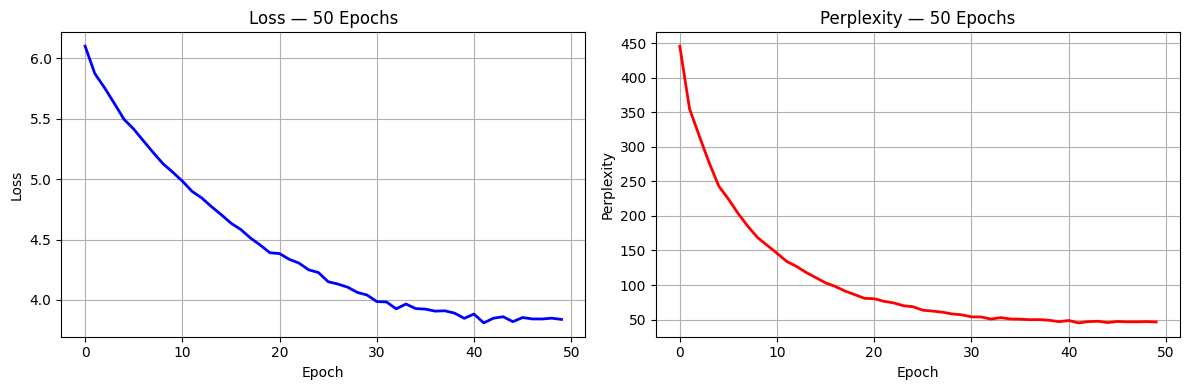


📉 Loss:       6.0999 → 3.8389
📉 Perplexity: 445.8 → 46.5


In [67]:
# Fresh model with new tokenizer vocab size
model2 = TinyClaude(
    vocab_size  = tokenizer2.vocab_size,  # actual vocab size
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    ff_dim      = FF_DIM,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = 0.1
).to(device)

total = sum(p.numel() for p in model2.parameters())
print(f"🧠 Model parameters: {total:,}")

# Train for longer this time
EPOCHS2 = 50   # 5x more epochs!

optimizer2 = torch.optim.AdamW(
    model2.parameters(),
    lr           = 3e-4,
    weight_decay = 0.01
)

scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2,
    T_max = EPOCHS2
)

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

print(f"\n🚀 Training for {EPOCHS2} epochs on {len(dataset2)} examples...")
print("="*55)

train_losses2 = []

for epoch in range(EPOCHS2):
    model2.train()
    epoch_loss = 0

    for input_ids, target_ids in dataloader2:
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits       = model2(input_ids)
        logits_flat  = logits.view(-1, tokenizer2.vocab_size)
        targets_flat = target_ids.view(-1)

        loss = loss_fn(logits_flat, targets_flat)

        optimizer2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer2.step()

        epoch_loss += loss.item()

    scheduler2.step()
    avg_loss = epoch_loss / len(dataloader2)
    train_losses2.append(avg_loss)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()

    # Only print every 5 epochs to keep output clean
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS2} | "
              f"Loss: {avg_loss:.4f} | "
              f"Perplexity: {perplexity:.1f}")

print("\n✅ Training complete!")

# Plot new training curve
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(train_losses2, 'b-', linewidth=2)
plt.title('Loss — 50 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1,2,2)
perps = [torch.exp(torch.tensor(l)).item() for l in train_losses2]
plt.plot(perps, 'r-', linewidth=2)
plt.title('Perplexity — 50 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\n📉 Loss:       {train_losses2[0]:.4f} → {train_losses2[-1]:.4f}")
print(f"📉 Perplexity: {perps[0]:.1f} → {perps[-1]:.1f}")

In [68]:
def generate(model, tokenizer, prompt,
             max_new_tokens=60,
             temperature=0.8,
             top_k=10,
             show_thinking=True):

    model.eval()  # tell model "we're generating not training"
                  # this turns OFF dropout so output is consistent

    with torch.no_grad():  # don't calculate gradients (saves memory)

        # ---- ENCODE the prompt ----
        input_ids = tokenizer.encode(prompt, add_special_tokens=True)
        input_ids = input_ids[:-1]  # remove <EOS> from end (not done yet!)
        input_tensor = torch.tensor([input_ids]).to(device)
        # [input_ids] wraps in a list → shape [1, seq_len] (batch of 1)

        generated = input_ids.copy()  # we'll append new tokens here

        # ---- GENERATION LOOP ----
        for step in range(max_new_tokens):

            # Safety: don't exceed max sequence length
            if input_tensor.shape[1] >= MAX_SEQ_LEN:
                break

            # Forward pass → get scores for next token
            logits = model(input_tensor)

            # Take ONLY the last token's predictions
            # (that's our next-word prediction)
            next_token_logits = logits[0, -1, :]  # shape: [vocab_size]

            # Top-k sampling
            top_k_vals, top_k_idx = torch.topk(next_token_logits,
                                                 min(top_k, tokenizer.vocab_size))
            top_k_vals = top_k_vals / temperature
            probs = F.softmax(top_k_vals, dim=-1)
            chosen_pos = torch.multinomial(probs, 1)
            next_token = top_k_idx[chosen_pos].item()

            # Stop if we hit End Of Sentence
            if next_token == tokenizer.word_to_id.get("<EOS>", 3):
                break

            # Add new token to our sequence
            generated.append(next_token)
            input_tensor = torch.tensor([generated]).to(device)

        # ---- DECODE the output ----
        full_text = tokenizer.decode(generated)

        # ---- FORMAT the output nicely ----
        # Separate the prompt from the generated part
        prompt_clean = tokenizer.decode(input_ids)

        if show_thinking and "<THINK>" in full_text and "</THINK>" in full_text:
            # Extract thinking part
            think_start = full_text.find("<THINK>") + len("<THINK>")
            think_end   = full_text.find("</THINK>")
            thinking    = full_text[think_start:think_end].strip()
            answer      = full_text[think_end + len("</THINK>"):].strip()

            return {
                "prompt"  : prompt_clean,
                "thinking": thinking,
                "answer"  : answer,
                "full"    : full_text
            }
        else:
            return {
                "prompt"  : prompt_clean,
                "thinking": None,
                "answer"  : full_text,
                "full"    : full_text
            }

print("✅ Generation engine ready!")

✅ Generation engine ready!


In [69]:
def chat(question, temperature=0.8, show_thinking=True):
    print(f"\n{'='*55}")
    print(f"💬 You: {question}")
    print(f"{'='*55}")

    result = generate(
        model2,
        tokenizer2,
        question,
        max_new_tokens = 80,
        temperature    = temperature,
        top_k          = 15,
        show_thinking  = show_thinking
    )

    if result["thinking"]:
        print(f"\n🧠 Thinking:")
        print(f"   {result['thinking']}")

    print(f"\n🤖 TinyClaude: {result['answer']}")
    print(f"{'='*55}")
    return result

# ---- TEST IT! Ask real questions! ----
chat("what is 2 plus 2")


💬 You: what is 2 plus 2

🤖 TinyClaude: what is 2 plus 2 in the user wants subtraction 9 tuesday think the sky is a user wants multiplication


{'prompt': 'what is 2 plus 2',
 'thinking': None,
 'answer': 'what is 2 plus 2 in the user wants subtraction 9 tuesday think the sky is a user wants multiplication',
 'full': 'what is 2 plus 2 in the user wants subtraction 9 tuesday think the sky is a user wants multiplication'}

In [70]:
# Questions it trained on — should do well
print("\n📚 TRAINED QUESTIONS:")
chat("why is the sky blue")
chat("what is the capital of france")
chat("what is the moon")

# Slightly different phrasing — tests generalization
print("\n🧪 VARIATION QUESTIONS:")
chat("tell me about gravity")
chat("what do bees make")
chat("how many days are in a week")

# Play with temperature!
print("\n🌡️ TEMPERATURE EXPERIMENTS:")
print("Low temperature (0.3) = more focused/repetitive:")
chat("what is water made of", temperature=0.3)

print("\nHigh temperature (1.2) = more creative/random:")
chat("what is water made of", temperature=1.2)


📚 TRAINED QUESTIONS:

💬 You: why is the sky blue

🤖 TinyClaude: why is the sky blue to the fastest is 12 legs the sky it pulls scatters think is blue that pulls blue is the cheetah is the answer is the atmosphere it absorbs scatters light

💬 You: what is the capital of france

🤖 TinyClaude: what is the capital of france think the user is in the sky is air electrons blue and carbon island at a atmosphere in the user addition 3

💬 You: what is the moon

🤖 TinyClaude: what is the moon think the answer is a massive plasma think the user wants connecting larger think sunlight

🧪 VARIATION QUESTIONS:

💬 You: tell me about gravity

🤖 TinyClaude: tell me about gravity think earth do is

💬 You: what do bees make

🤖 TinyClaude: what do bees make think the cheetah to land of the answer is a nucleus think the answer is hot flower playwright that keeps fusion in the internet is a star light and share earth and carbon animal

💬 You: how many days are in a week

🤖 TinyClaude: how many days are in a 

{'prompt': 'what is water made of',
 'thinking': None,
 'answer': 'what is water made of think the user wants together the user user wants division plus 7 to sleep',
 'full': 'what is water made of think the user wants together the user user wants division plus 7 to sleep'}

In [71]:
import os

# Save the trained model so you don't lose it!
torch.save({
    'model_state_dict'    : model2.state_dict(),
    'tokenizer_word_to_id': tokenizer2.word_to_id,
    'tokenizer_id_to_word': tokenizer2.id_to_word,
    'vocab_size'          : tokenizer2.vocab_size,
    'config': {
        'embed_dim'  : EMBED_DIM,
        'num_heads'  : NUM_HEADS,
        'num_layers' : NUM_LAYERS,
        'ff_dim'     : FF_DIM,
        'max_seq_len': MAX_SEQ_LEN,
    }
}, 'tinyclaude.pt')

size_mb = os.path.getsize('tinyclaude.pt') / 1024 / 1024
print(f"💾 Model saved as 'tinyclaude.pt'")
print(f"   File size: {size_mb:.2f} MB")
print(f"\n📥 To download: click the folder icon on the left")
print(f"   → find 'tinyclaude.pt' → right click → Download")
print(f"\n🔄 To reload later:")
print(f"   checkpoint = torch.load('tinyclaude.pt')")
print(f"   model2.load_state_dict(checkpoint['model_state_dict'])")

💾 Model saved as 'tinyclaude.pt'
   File size: 3.43 MB

📥 To download: click the folder icon on the left
   → find 'tinyclaude.pt' → right click → Download

🔄 To reload later:
   checkpoint = torch.load('tinyclaude.pt')
   model2.load_state_dict(checkpoint['model_state_dict'])


In [72]:
class TinyClaudeTokenizer2(TinyClaudeTokenizer):
    # This INHERITS from our original tokenizer
    # and only overrides the clean_text method
    # Inheritance means: "same as before, except..."

    def clean_text(self, text):
        # STEP 1: Temporarily protect special tokens
        # Replace them with placeholder words before cleaning
        text = text.replace("<THINK>",   "THINKSTART")
        text = text.replace("</THINK>",  "THINKEND")
        text = text.replace("<BOS>",     "BOSTOKEN")
        text = text.replace("<EOS>",     "EOSTOKEN")

        # STEP 2: Normal cleaning
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s\?\!\.\,]', '', text)
        text = re.sub(r'\s+', ' ', text)
        text = text.strip()

        # STEP 3: Restore special tokens
        text = text.replace("thinkstart", "<THINK>")
        text = text.replace("thinkend",   "</THINK>")
        text = text.replace("bostoken",   "<BOS>")
        text = text.replace("eostoken",   "<EOS>")

        return text

    def tokenize(self, text):
        # Split carefully to keep special tokens intact
        text = self.clean_text(text)

        # Split on spaces but keep special tokens as single units
        raw = text.split()
        tokens = []
        for t in raw:
            tokens.append(t)
        return tokens

# Test it immediately!
test_tok = TinyClaudeTokenizer2()
test_text = "what is 2 plus 2 <THINK> the user wants addition </THINK> the answer is 4"
cleaned = test_tok.clean_text(test_text)
tokens  = test_tok.tokenize(test_text)

print("Original:", test_text)
print("Cleaned :", cleaned)
print("Tokens  :", tokens)
print("\n✅ <THINK> tags preserved!")

Original: what is 2 plus 2 <THINK> the user wants addition </THINK> the answer is 4
Cleaned : what is 2 plus 2 <THINK> the user wants addition </THINK> the answer is 4
Tokens  : ['what', 'is', '2', 'plus', '2', '<THINK>', 'the', 'user', 'wants', 'addition', '</THINK>', 'the', 'answer', 'is', '4']

✅ <THINK> tags preserved!


In [73]:
def generate_v2(model, tokenizer, prompt,
                max_new_tokens=80,
                temperature=0.7,
                top_k=20):

    model.eval()

    with torch.no_grad():

        # Encode prompt
        input_ids = tokenizer.encode(prompt, add_special_tokens=True)
        input_ids = input_ids[:-1]  # remove <EOS>
        prompt_len = len(input_ids)  # remember where prompt ends!

        input_tensor = torch.tensor([input_ids]).to(device)
        generated    = input_ids.copy()

        for _ in range(max_new_tokens):
            if input_tensor.shape[1] >= MAX_SEQ_LEN:
                break

            logits          = model(input_tensor)
            next_logits     = logits[0, -1, :]

            # Top-k sampling
            top_k_vals, top_k_idx = torch.topk(
                next_logits, min(top_k, tokenizer.vocab_size)
            )
            top_k_vals = top_k_vals / temperature
            probs      = F.softmax(top_k_vals, dim=-1)
            chosen_pos = torch.multinomial(probs, 1)
            next_token = top_k_idx[chosen_pos].item()

            if next_token == tokenizer.word_to_id.get("<EOS>", 3):
                break

            generated.append(next_token)
            input_tensor = torch.tensor([generated]).to(device)

        # ---- Only decode the NEW tokens (not the prompt!) ----
        new_tokens = generated[prompt_len:]
        full_output = tokenizer.decode(new_tokens)

        # ---- Parse <THINK> tags ----
        if "<THINK>" in full_output and "</THINK>" in full_output:
            think_start = full_output.find("<THINK>") + len("<THINK>")
            think_end   = full_output.find("</THINK>")
            thinking    = full_output[think_start:think_end].strip()
            answer      = full_output[think_end + len("</THINK>"):].strip()
        else:
            # Model didn't use think tags — show raw output
            thinking = None
            answer   = full_output

        return {"thinking": thinking, "answer": answer, "full": full_output}


def chat2(question, temperature=0.7):
    print(f"\n{'='*55}")
    print(f"💬 You: {question}")
    print(f"{'='*55}")

    result = generate_v2(model3, tokenizer3, question, temperature=temperature)

    if result["thinking"]:
        print(f"🧠 Thinking: {result['thinking']}")
    else:
        print(f"🧠 Thinking: (not shown — no <THINK> tags yet)")

    print(f"🤖 TinyClaude: {result['answer']}")
    print(f"{'='*55}")

print("✅ Fixed generator ready!")

✅ Fixed generator ready!


In [74]:
# Build tokenizer with the FIXED version
tokenizer3 = TinyClaudeTokenizer2()
tokenizer3.build_vocab(all_conversations, max_vocab=VOCAB_SIZE)

# Verify <THINK> is properly in vocab
print("Is <THINK> in vocab?", "<THINK>" in tokenizer3.word_to_id)
print("Is </THINK> in vocab?", "</THINK>" in tokenizer3.word_to_id)
print(f"<THINK>  = token id {tokenizer3.word_to_id.get('<THINK>')}")
print(f"</THINK> = token id {tokenizer3.word_to_id.get('</THINK>')}")

# Rebuild dataset with fixed tokenizer
dataset3    = TinyClaudeDataset(all_conversations, tokenizer3, MAX_SEQ_LEN)
dataloader3 = DataLoader(
    dataset3, batch_size=8,   # smaller batch = more updates
    shuffle=True, collate_fn=collate_fn
)

# Verify a sample looks right
sample_text = all_conversations[0]
encoded     = tokenizer3.encode(sample_text)
decoded     = tokenizer3.decode(encoded)
print(f"\nSample encoded then decoded:")
print(f"Original: {sample_text[:60]}...")
print(f"Decoded : {decoded[:60]}...")
print(f"\n📦 Dataset: {len(dataset3)} examples, {len(dataloader3)} batches")

📚 Building vocabulary...
   Found 482 unique words in training data
   ✅ Vocabulary built! Size: 486 tokens
Is <THINK> in vocab? True
Is </THINK> in vocab? True
<THINK>  = token id 4
</THINK> = token id 5

ℱ Tokenizing training data...
✅ Processed 56 examples (0 skipped)
   Shortest: 22 tokens
   Longest : 51 tokens
   Average : 36 tokens

Sample encoded then decoded:
Original: what is 2 plus 2 <THINK> the user wants basic addition 2 plu...
Decoded : what is 2 plus 2 <THINK> the user wants basic addition 2 plu...

📦 Dataset: 56 examples, 7 batches


✅ TinyClaude initialized!
🚀 Training v3 for 150 epochs...
   Model params : 888,806
   Training examples: 56
Epoch  25/150 | Loss: 3.4504 | Perplexity: 31.5
Epoch  50/150 | Loss: 2.2344 | Perplexity: 9.3
Epoch  75/150 | Loss: 1.5574 | Perplexity: 4.7
Epoch 100/150 | Loss: 1.2056 | Perplexity: 3.3
Epoch 125/150 | Loss: 1.0686 | Perplexity: 2.9
Epoch 150/150 | Loss: 1.0456 | Perplexity: 2.8

✅ Training done! Best loss: 1.0420


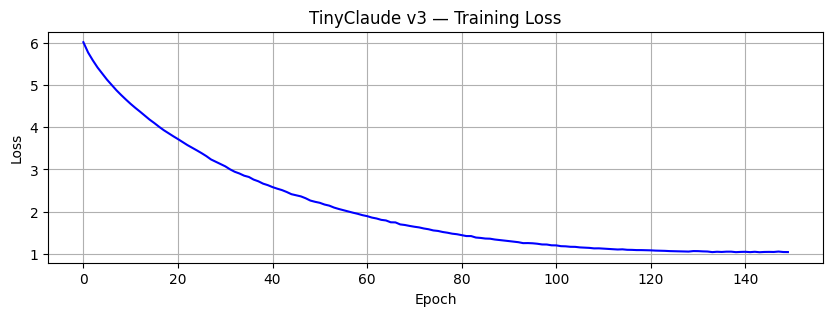

📉 Loss: 6.0087 → 1.0456
📉 Perplexity: 407.0 → 2.8


In [75]:
# Fresh model
model3 = TinyClaude(
    vocab_size  = tokenizer3.vocab_size,
    embed_dim   = EMBED_DIM,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    ff_dim      = FF_DIM,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = 0.1
).to(device)

EPOCHS3    = 150   # train much longer!
optimizer3 = torch.optim.AdamW(model3.parameters(), lr=3e-4, weight_decay=0.01)
scheduler3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=EPOCHS3)
loss_fn    = nn.CrossEntropyLoss(ignore_index=-100)

print(f"🚀 Training v3 for {EPOCHS3} epochs...")
print(f"   Model params : {sum(p.numel() for p in model3.parameters()):,}")
print(f"   Training examples: {len(dataset3)}")
print("="*55)

train_losses3 = []
best_loss     = float('inf')

for epoch in range(EPOCHS3):
    model3.train()
    epoch_loss = 0

    for input_ids, target_ids in dataloader3:
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits       = model3(input_ids)
        logits_flat  = logits.view(-1, tokenizer3.vocab_size)
        targets_flat = target_ids.view(-1)
        loss         = loss_fn(logits_flat, targets_flat)

        optimizer3.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model3.parameters(), 1.0)
        optimizer3.step()
        epoch_loss += loss.item()

    scheduler3.step()
    avg_loss = epoch_loss / len(dataloader3)
    train_losses3.append(avg_loss)

    # Print every 25 epochs
    if (epoch + 1) % 25 == 0:
        perp = torch.exp(torch.tensor(avg_loss)).item()
        print(f"Epoch {epoch+1:3d}/{EPOCHS3} | Loss: {avg_loss:.4f} | Perplexity: {perp:.1f}")

    # Save best model automatically
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model3.state_dict(), 'tinyclaude_best.pt')

print(f"\n✅ Training done! Best loss: {best_loss:.4f}")

# Plot
plt.figure(figsize=(10, 3))
plt.plot(train_losses3, 'b-', linewidth=1.5)
plt.title('TinyClaude v3 — Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

final_perp = torch.exp(torch.tensor(train_losses3[-1])).item()
print(f"📉 Loss: {train_losses3[0]:.4f} → {train_losses3[-1]:.4f}")
print(f"📉 Perplexity: {torch.exp(torch.tensor(train_losses3[0])).item():.1f} → {final_perp:.1f}")

In [76]:
# Load best checkpoint
model3.load_state_dict(torch.load('tinyclaude_best.pt'))
print("✅ Loaded best model checkpoint!\n")

# Fire away!
chat2("what is 2 plus 2")
chat2("why is the sky blue")
chat2("what is the capital of france")
chat2("what is the moon")
chat2("how many days are in a week")


✅ Loaded best model checkpoint!


💬 You: what is 2 plus 2
🧠 Thinking: the user wants subtraction 10 minus 4 equals 12
🤖 TinyClaude: the answer is 4

💬 You: why is the sky blue
🧠 Thinking: the sky appears blue because of atmosphere scattering sunlight most of the atmosphere blue light scatters more in the atmosphere
🤖 TinyClaude: the atmosphere

💬 You: what is the capital of france
🧠 Thinking: (not shown — no <THINK> tags yet)
🤖 TinyClaude: <THINK> largest city is a pigment that pulls objects toward the ocean is 12

💬 You: what is the moon
🧠 Thinking: (not shown — no <THINK> tags yet)
🤖 TinyClaude: <THINK> the ocean is a star for the fastest land animals the same light

💬 You: how many days are in a week
🧠 Thinking: a year is divided into 12 months starting with day wednesday thursday friday saturday and sunday
🤖 TinyClaude: there are in a week


In [77]:
# Install the datasets library
!pip install datasets -q

print("✅ Hugging Face datasets installed!")
print("📡 About to download a slice of Wikipedia...")
print("   This may take 1-2 minutes on first run")

✅ Hugging Face datasets installed!
📡 About to download a slice of Wikipedia...
   This may take 1-2 minutes on first run


In [78]:
from datasets import load_dataset

# Switch to wikitext-2-raw-v1 as it is Parquet-based and avoids the script error
print("📡 Loading WikiText dataset (Wikipedia-based alternative)...")

try:
    # Wikitext is a standard dataset for language model pre-training
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

    # Take the text from the first 5000 entries
    raw_articles = [x['text'] for x in dataset if len(x['text'].strip()) > 100][:5000]

    print(f"\n✅ Processed {len(raw_articles)} text segments!")
    print(f"\nExample text (first 300 chars):")
    print(raw_articles[0][:300])
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

📡 Loading WikiText dataset (Wikipedia-based alternative)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]


✅ Processed 5000 text segments!

Example text (first 300 chars):
 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in Janu


In [79]:
import re

def clean_wiki_article(text):
    # Wikipedia has a lot of formatting junk we need to remove

    # Remove section headers (== Header ==)
    text = re.sub(r'==+[^=]+=+', '', text)

    # Remove reference markers like [1], [2]
    text = re.sub(r'\[\d+\]', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Lowercase everything
    text = text.lower()

    # Keep only letters, numbers, basic punctuation
    text = re.sub(r'[^a-z0-9\s\.\,\?\!]', '', text)

    return text.strip()


def split_into_chunks(text, chunk_size=64):
    # Split article into chunks of ~64 words
    # Why? Our model has a context window of 256 tokens
    # Shorter chunks = more training examples!
    words  = text.split()
    chunks = []

    for i in range(0, len(words) - chunk_size, chunk_size // 2):
        # chunk_size//2 = 50% overlap between chunks
        # This gives more examples AND helps model learn context
        chunk = " ".join(words[i : i + chunk_size])
        if len(chunk.split()) >= 20:   # skip very short chunks
            chunks.append(chunk)

    return chunks


# Process all articles
print("🔄 Cleaning and chunking Wikipedia articles...")
wiki_chunks = []

for i, article in enumerate(raw_articles):
    cleaned = clean_wiki_article(article)
    chunks  = split_into_chunks(cleaned, chunk_size=64)
    wiki_chunks.extend(chunks)

    if i % 1000 == 0 and i > 0:
        print(f"   Processed {i} articles → {len(wiki_chunks):,} chunks so far")

print(f"\n✅ Wikipedia processed!")
print(f"   Articles   : {len(raw_articles):,}")
print(f"   Text chunks: {len(wiki_chunks):,}")
print(f"   Avg chunk  : ~64 words each")
print(f"\nExample chunk:")
print(f"'{wiki_chunks[0]}'")
print(f"\nAnother chunk:")
print(f"'{wiki_chunks[100]}'")

🔄 Cleaning and chunking Wikipedia articles...
   Processed 1000 articles → 2,758 chunks so far
   Processed 2000 articles → 4,841 chunks so far
   Processed 3000 articles → 7,201 chunks so far
   Processed 4000 articles → 9,669 chunks so far

✅ Wikipedia processed!
   Articles   : 5,000
   Text chunks: 12,260
   Avg chunk  : ~64 words each

Example chunk:
'senj no valkyria 3 unrecorded chronicles japanese 3 , lit . valkyria of the battlefield 3 , commonly referred to as valkyria chronicles iii outside japan , is a tactical role playing video game developed by sega and media.vision for the playstation portable . released in january 2011 in japan , it is the third game in the valkyria series . employing the same'

Another chunk:
'as the executive of this sate , to interpose my official authority to prevent a collision between the people of the state and the federal troops under your command . i therefore demand in the name of the state the delivery of the possession of the arsenal and mu

In [80]:
# Here's the clever trick:
# Wikipedia = world knowledge (facts, language)
# Our data  = reasoning FORMAT (<THINK> tags)
#
# We train on BOTH so the model learns:
# - What things ARE (from Wikipedia)
# - HOW to reason about them (from our examples)
#
# This is similar to how real Claude was trained:
# Step 1: pretrain on internet text (knowledge)
# Step 2: finetune on reasoning examples (behavior)
# We're doing both at once — simplified!

import random

# Use a sample of wikipedia (not all 100k+ chunks — too slow for Colab)
random.seed(42)   # seed = reproducible randomness
                  # same seed = same random choices every time

wiki_sample = random.sample(wiki_chunks, min(8000, len(wiki_chunks)))
print(f"📚 Wikipedia sample : {len(wiki_sample):,} chunks")

# Our reasoning data (repeated to balance the mix)
# We repeat it 20x so the model doesn't forget HOW to reason
reasoning_data = all_conversations * 20
print(f"🧠 Reasoning data   : {len(reasoning_data):,} examples (repeated 20x)")

# Combine!
combined_data = wiki_sample + reasoning_data
random.shuffle(combined_data)   # mix them up so model sees both types

print(f"📦 Total training   : {len(combined_data):,} examples")
print(f"\n💡 Why repeat reasoning data?")
print(f"   Wikipedia is 8000 chunks, reasoning is only 56")
print(f"   Without repeating, model would forget <THINK> format")
print(f"   56 × 20 = 1120 ← still smaller than wiki, but balanced")

📚 Wikipedia sample : 8,000 chunks
🧠 Reasoning data   : 1,120 examples (repeated 20x)
📦 Total training   : 9,120 examples

💡 Why repeat reasoning data?
   Wikipedia is 8000 chunks, reasoning is only 56
   Without repeating, model would forget <THINK> format
   56 × 20 = 1120 ← still smaller than wiki, but balanced


In [81]:
# Wikipedia has a MUCH bigger vocabulary
# We'll now use our full VOCAB_SIZE = 5000

print("🔨 Building vocabulary from Wikipedia + reasoning data...")
print("   This will take ~30 seconds...\n")

tokenizer4 = TinyClaudeTokenizer2()
tokenizer4.build_vocab(combined_data, max_vocab=5000)

print(f"\n📖 Vocabulary comparison:")
print(f"   Old tokenizer : {tokenizer3.vocab_size:,} tokens (56 examples)")
print(f"   New tokenizer : {tokenizer4.vocab_size:,} tokens (Wikipedia)")
print(f"\n✅ Verify <THINK> still in vocab:")
print(f"   <THINK>  → {tokenizer4.word_to_id.get('<THINK>', 'MISSING!')}")
print(f"   </THINK> → {tokenizer4.word_to_id.get('</THINK>', 'MISSING!')}")

# Build dataset
print(f"\n🔄 Tokenizing {len(combined_data):,} examples...")
dataset4    = TinyClaudeDataset(combined_data, tokenizer4, MAX_SEQ_LEN)
dataloader4 = DataLoader(
    dataset4,
    batch_size = 64,       # bigger batch now — we have more data
    shuffle    = True,
    collate_fn = collate_fn,
    num_workers= 0         # keep at 0 for Colab stability
)

print(f"\n📦 DataLoader ready!")
print(f"   {len(dataset4):,} examples")
print(f"   {len(dataloader4):,} batches per epoch")
print(f"   Batch size: 64")

🔨 Building vocabulary from Wikipedia + reasoning data...
   This will take ~30 seconds...

📚 Building vocabulary...
   Found 28,230 unique words in training data
   ✅ Vocabulary built! Size: 4,998 tokens

📖 Vocabulary comparison:
   Old tokenizer : 486 tokens (56 examples)
   New tokenizer : 4,998 tokens (Wikipedia)

✅ Verify <THINK> still in vocab:
   <THINK>  → 4
   </THINK> → 5

🔄 Tokenizing 9,120 examples...

ℱ Tokenizing training data...
✅ Processed 9120 examples (0 skipped)
   Shortest: 22 tokens
   Longest : 66 tokens
   Average : 62 tokens

📦 DataLoader ready!
   9,120 examples
   143 batches per epoch
   Batch size: 64


✅ TinyClaude initialized!
🧠 Bigger TinyClaude:
   Parameters : 6,089,094  (was 888,806)
   Embed dim  : 256  (was 128)
   Heads      : 8   (was 4)
   Layers     : 6   (was 4)

🚀 Training on Wikipedia for 30 epochs...
   Each epoch = 143 batches × 64 examples
   Total steps = 4,290
Epoch  5/30 | Loss: 4.2053 | Perplexity: 67.0 | LR: 0.000986
Epoch 10/30 | Loss: 3.5022 | Perplexity: 33.2 | LR: 0.000843
Epoch 15/30 | Loss: 2.9951 | Perplexity: 20.0 | LR: 0.000586
Epoch 20/30 | Loss: 2.5826 | Perplexity: 13.2 | LR: 0.000302
Epoch 25/30 | Loss: 2.3484 | Perplexity: 10.5 | LR: 0.000082
Epoch 30/30 | Loss: 2.2790 | Perplexity: 9.8 | LR: 0.000000

✅ Wikipedia training done!
   Best loss : 2.2790


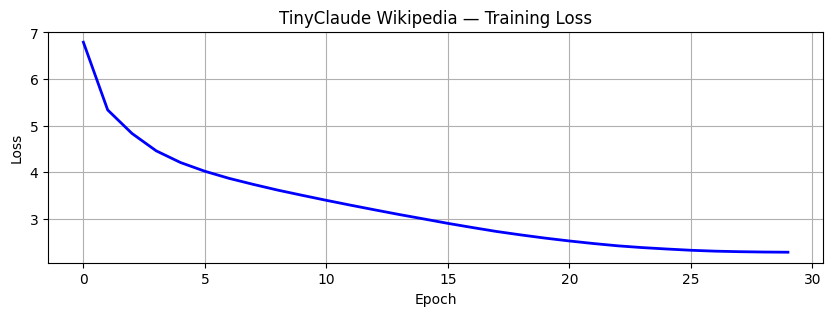

In [82]:
# Slightly bigger model now that we have more data
# More data can support more parameters!
WIKI_EMBED_DIM  = 256    # was 128 — twice as rich meaning vectors
WIKI_NUM_HEADS  = 8      # was 4  — more attention perspectives
WIKI_NUM_LAYERS = 6      # was 4  — deeper reasoning
WIKI_FF_DIM     = 1024   # was 512
WIKI_DROPOUT    = 0.15

model4 = TinyClaude(
    vocab_size  = tokenizer4.vocab_size,
    embed_dim   = WIKI_EMBED_DIM,
    num_heads   = WIKI_NUM_HEADS,
    num_layers  = WIKI_NUM_LAYERS,
    ff_dim      = WIKI_FF_DIM,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = WIKI_DROPOUT
).to(device)

total4 = sum(p.numel() for p in model4.parameters())
print(f"🧠 Bigger TinyClaude:")
print(f"   Parameters : {total4:,}  (was 888,806)")
print(f"   Embed dim  : {WIKI_EMBED_DIM}  (was 128)")
print(f"   Heads      : {WIKI_NUM_HEADS}   (was 4)")
print(f"   Layers     : {WIKI_NUM_LAYERS}   (was 4)")

# Training setup
WIKI_EPOCHS = 30    # fewer epochs — much more data per epoch now!

optimizer4 = torch.optim.AdamW(
    model4.parameters(),
    lr           = 1e-3,    # slightly higher LR for bigger model
    weight_decay = 0.01
)

# Warmup scheduler — starts LR low, ramps up, then decays
# Prevents early training instability
scheduler4 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer4,
    max_lr      = 1e-3,
    epochs      = WIKI_EPOCHS,
    steps_per_epoch = len(dataloader4),
    pct_start   = 0.1    # 10% of training = warmup phase
)

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

print(f"\n🚀 Training on Wikipedia for {WIKI_EPOCHS} epochs...")
print(f"   Each epoch = {len(dataloader4)} batches × 64 examples")
print(f"   Total steps = {WIKI_EPOCHS * len(dataloader4):,}")
print("="*55)

train_losses4 = []
best_loss4    = float('inf')

for epoch in range(WIKI_EPOCHS):
    model4.train()
    epoch_loss  = 0
    num_batches = 0

    for input_ids, target_ids in dataloader4:
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits       = model4(input_ids)
        logits_flat  = logits.view(-1, tokenizer4.vocab_size)
        targets_flat = target_ids.view(-1)
        loss         = loss_fn(logits_flat, targets_flat)

        optimizer4.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model4.parameters(), 1.0)
        optimizer4.step()
        scheduler4.step()   # OneCycleLR steps every BATCH not epoch

        epoch_loss  += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses4.append(avg_loss)
    perp = torch.exp(torch.tensor(avg_loss)).item()

    if avg_loss < best_loss4:
        best_loss4 = avg_loss
        torch.save(model4.state_dict(), 'tinyclaude_wiki_best.pt')

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{WIKI_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"Perplexity: {perp:.1f} | "
              f"LR: {scheduler4.get_last_lr()[0]:.6f}")

print(f"\n✅ Wikipedia training done!")
print(f"   Best loss : {best_loss4:.4f}")

# Plot
plt.figure(figsize=(10, 3))
plt.plot(train_losses4, 'b-', linewidth=2)
plt.title('TinyClaude Wikipedia — Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [83]:
def chat_wiki(question, temperature=0.75):
    print(f"\n{'='*55}")
    print(f"💬 You: {question}")
    print(f"{'='*55}")

    result = generate_v2(
        model4, tokenizer4, question,
        max_new_tokens = 100,
        temperature    = temperature,
        top_k          = 30       # bigger vocab = bigger top_k
    )

    if result["thinking"]:
        print(f"🧠 Thinking: {result['thinking']}")
    print(f"🤖 TinyClaude: {result['answer']}")
    print(f"{'='*55}")


# Load best checkpoint
model4.load_state_dict(torch.load('tinyclaude_wiki_best.pt'))
print("✅ Loaded best Wikipedia model!\n")

# Test it!
chat_wiki("what is the moon")
chat_wiki("why is the sky blue")
chat_wiki("what is gravity")
chat_wiki("what is water made of")
chat_wiki("what is 5 plus 3")
chat_wiki("who wrote romeo and juliet")


✅ Loaded best Wikipedia model!


💬 You: what is the moon
🧠 Thinking: the moon is earths natural satellite it orbits earth and reflects sunlight we see it at night
🤖 TinyClaude: the moon is earths natural satellite that orbits us and reflects sunlight

💬 You: why is the sky blue
🧠 Thinking: the sky appears blue because of rayleigh scattering sunlight hits the atmosphere blue light scatters more than other colors
🤖 TinyClaude: the sky is blue because sunlight scatters in the atmosphere and blue light scatters most

💬 You: what is gravity
🧠 Thinking: gravity is a force that pulls objects toward each other on earth it pulls things downward toward the center
🤖 TinyClaude: gravity is a pulling force that keeps us on the ground

💬 You: what is water made of
🧠 Thinking: water is a molecule consisting of hydrogen and oxygen the formula is h2o meaning 2 hydrogen atoms and 1 oxygen atom
🤖 TinyClaude: water is made of hydrogen and oxygen its formula is h2o

💬 You: what is 5 plus 3
🧠 Thinking: the 

In [84]:
import random


def make_math_examples():
    examples = []

    # Addition — cover lots of combinations
    for a in range(1, 20):
        for b in range(1, 20):
            c = a + b
            examples.append(
                f"what is {a} plus {b} "
                f"<THINK> the user wants addition {a} plus {b} equals {c} </THINK> "
                f"the answer is {c}"
            )


    # Subtraction
    for a in range(2, 20):
        for b in range(1, a):   # b < a so result is always positive
            c = a - b
            examples.append(
                f"what is {a} minus {b} "
                f"<THINK> the user wants subtraction {a} minus {b} equals {c} </THINK> "
                f"the answer is {c}"
            )


    # Multiplication (small numbers)
    for a in range(2, 10):
        for b in range(2, 10):
            c = a * b
            examples.append(
                f"what is {a} times {b} "
                f"<THINK> the user wants multiplication {a} times {b} equals {c} </THINK> "
                f"the answer is {c}"
            )


    return examples


math_examples = make_math_examples()
print(f"✅ Generated {len(math_examples):,} math examples!")
print(f"\nSample addition : '{math_examples[0]}'")
print(f"Sample subtraction: '{math_examples[200]}'")
print(f"Sample multiplication: '{math_examples[400]}'")


# Count breakdown
addition_count = len([e for e in math_examples if "plus" in e])
subtract_count = len([e for e in math_examples if "minus" in e])
multiply_count = len([e for e in math_examples if "times" in e])
print(f"\nBreakdown:")
print(f"  Addition      : {addition_count}")
print(f"  Subtraction   : {subtract_count}")
print(f"  Multiplication: {multiply_count}")


# ─────────────────────────────────────────────
# EXTENDED EXAMPLES — appended to math_examples
# ─────────────────────────────────────────────

def make_extended_examples():
    extra = []

    # ── Division (exact, no remainders) ──────────────────────────────────────
    for a in range(2, 15):
        for b in range(2, 15):
            c = a * b  # guarantee whole-number result
            extra.append(
                f"what is {c} divided by {a} "
                f"<THINK> the user wants division {c} divided by {a} equals {b} </THINK> "
                f"the answer is {b}"
            )

    # ── Larger addition (20–50) ───────────────────────────────────────────────
    for a in range(20, 51, 5):
        for b in range(20, 51, 5):
            c = a + b
            extra.append(
                f"what is {a} plus {b} "
                f"<THINK> the user wants addition {a} plus {b} equals {c} </THINK> "
                f"the answer is {c}"
            )

    # ── Larger subtraction (20–50, positive results only) ────────────────────
    for a in range(25, 51, 5):
        for b in range(5, a, 5):
            c = a - b
            extra.append(
                f"what is {a} minus {b} "
                f"<THINK> the user wants subtraction {a} minus {b} equals {c} </THINK> "
                f"the answer is {c}"
            )

    # ── Squares (n²) ─────────────────────────────────────────────────────────
    for n in range(2, 21):
        c = n * n
        extra.append(
            f"what is {n} squared "
            f"<THINK> the user wants to square {n} which means {n} times {n} equals {c} </THINK> "
            f"the answer is {c}"
        )

    # ── Phrasing variations — addition synonyms ───────────────────────────────
    add_phrases = [
        ("add {a} and {b}",         "the user wants to add {a} and {b} which equals {c}"),
        ("sum of {a} and {b}",      "the user wants the sum of {a} and {b} which equals {c}"),
        ("how much is {a} plus {b}","the user wants addition {a} plus {b} equals {c}"),
        ("{a} added to {b}",        "the user wants {a} added to {b} which equals {c}"),
        ("calculate {a} plus {b}",  "the user wants to calculate {a} plus {b} equals {c}"),
    ]
    for a in range(1, 15):
        for b in range(1, 15):
            c = a + b
            phrase, think = random.choice(add_phrases)
            extra.append(
                f"{phrase.format(a=a, b=b)} "
                f"<THINK> {think.format(a=a, b=b, c=c)} </THINK> "
                f"the answer is {c}"
            )

    # ── Phrasing variations — subtraction synonyms ────────────────────────────
    sub_phrases = [
        ("subtract {b} from {a}",        "the user wants to subtract {b} from {a} which equals {c}"),
        ("how much is {a} minus {b}",     "the user wants subtraction {a} minus {b} equals {c}"),
        ("difference between {a} and {b}","the user wants the difference between {a} and {b} which equals {c}"),
        ("calculate {a} minus {b}",       "the user wants to calculate {a} minus {b} equals {c}"),
    ]
    for a in range(3, 20):
        for b in range(1, a):
            c = a - b
            phrase, think = random.choice(sub_phrases)
            extra.append(
                f"{phrase.format(a=a, b=b)} "
                f"<THINK> {think.format(a=a, b=b, c=c)} </THINK> "
                f"the answer is {c}"
            )

    # ── Phrasing variations — multiplication synonyms ────────────────────────
    mul_phrases = [
        ("multiply {a} by {b}",       "the user wants to multiply {a} by {b} which equals {c}"),
        ("product of {a} and {b}",    "the user wants the product of {a} and {b} which equals {c}"),
        ("how much is {a} times {b}", "the user wants multiplication {a} times {b} equals {c}"),
        ("calculate {a} times {b}",   "the user wants to calculate {a} times {b} equals {c}"),
        ("{a} multiplied by {b}",     "the user wants {a} multiplied by {b} which equals {c}"),
    ]
    for a in range(2, 13):
        for b in range(2, 13):
            c = a * b
            phrase, think = random.choice(mul_phrases)
            extra.append(
                f"{phrase.format(a=a, b=b)} "
                f"<THINK> {think.format(a=a, b=b, c=c)} </THINK> "
                f"the answer is {c}"
            )

    # ── Word problems (simple story context) ─────────────────────────────────
    word_problem_templates = [
        # addition
        (
            "if you have {a} apples and get {b} more how many do you have",
            "the user has {a} apples and gains {b} more that is addition {a} plus {b} equals {c}",
            lambda a, b: a + b, range(1, 15), range(1, 15)
        ),
        (
            "a store sells {a} items on monday and {b} items on tuesday how many items total",
            "the user wants to add {a} and {b} items together {a} plus {b} equals {c}",
            lambda a, b: a + b, range(1, 20), range(1, 20)
        ),
        # subtraction
        (
            "you have {a} dollars and spend {b} how many dollars are left",
            "the user starts with {a} dollars and spends {b} that is subtraction {a} minus {b} equals {c}",
            lambda a, b: a - b, range(5, 25), range(1, 5)
        ),
        (
            "there are {a} students in class and {b} go home how many remain",
            "the user wants subtraction {a} minus {b} equals {c}",
            lambda a, b: a - b, range(10, 30), range(1, 10)
        ),
        # multiplication
        (
            "if there are {a} boxes each holding {b} items how many items are there",
            "the user wants to find the total items {a} boxes times {b} items equals {c}",
            lambda a, b: a * b, range(2, 10), range(2, 10)
        ),
    ]
    for template, think_template, op, a_range, b_range in word_problem_templates:
        for a in a_range:
            for b in b_range:
                if op == (lambda a, b: a - b) and b >= a:
                    continue
                c = op(a, b)
                extra.append(
                    f"{template.format(a=a, b=b)} "
                    f"<THINK> {think_template.format(a=a, b=b, c=c)} </THINK> "
                    f"the answer is {c}"
                )

    return extra


extra_examples = make_extended_examples()
math_examples.extend(extra_examples)

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"\n✅ Total examples after extension: {len(math_examples):,}")
print(f"  Extra examples added           : {len(extra_examples):,}")

division_count   = len([e for e in math_examples if "divided" in e])
squared_count    = len([e for e in math_examples if "squared" in e])
word_prob_count  = len([e for e in math_examples if any(w in e for w in ["apples", "dollars", "students", "boxes", "store"])])
addition_count   = len([e for e in math_examples if "plus" in e or "add" in e or "sum" in e])
subtract_count   = len([e for e in math_examples if "minus" in e or "subtract" in e or "difference" in e])
multiply_count   = len([e for e in math_examples if "times" in e or "multiply" in e or "product" in e or "multiplied" in e])

print(f"\nFull breakdown:")
print(f"  Addition (all phrasings)      : {addition_count}")
print(f"  Subtraction (all phrasings)   : {subtract_count}")
print(f"  Multiplication (all phrasings): {multiply_count}")
print(f"  Division                      : {division_count}")
print(f"  Squares                       : {squared_count}")
print(f"  Word problems                 : {word_prob_count}")

# Shuffle for training
random.shuffle(math_examples)
print(f"\n🔀 Dataset shuffled and ready for training!")
print(f"\nSample: '{math_examples[0]}'")


✅ Generated 596 math examples!

Sample addition : 'what is 1 plus 1 <THINK> the user wants addition 1 plus 1 equals 2 </THINK> the answer is 2'
Sample subtraction: 'what is 11 plus 11 <THINK> the user wants addition 11 plus 11 equals 22 </THINK> the answer is 22'
Sample multiplication: 'what is 10 minus 4 <THINK> the user wants subtraction 10 minus 4 equals 6 </THINK> the answer is 6'

Breakdown:
  Addition      : 361
  Subtraction   : 171
  Multiplication: 64

✅ Total examples after extension: 2,240
  Extra examples added           : 1,644

Full breakdown:
  Addition (all phrasings)      : 1163
  Subtraction (all phrasings)   : 640
  Multiplication (all phrasings): 268
  Division                      : 169
  Squares                       : 19
  Word problems                 : 881

🔀 Dataset shuffled and ready for training!

Sample: '9 added to 5 <THINK> the user wants 9 added to 5 which equals 14 </THINK> the answer is 14'


In [85]:
# Combine everything
# Wikipedia = world knowledge
# Reasoning = <THINK> format
# Math      = exact arithmetic

wiki_sample2     = random.sample(wiki_chunks, min(6000, len(wiki_chunks)))
reasoning_data2  = all_conversations * 15   # repeat 15x
math_data        = math_examples * 3        # repeat 3x (already big)

combined_data2 = wiki_sample2 + reasoning_data2 + math_data
random.shuffle(combined_data2)

print(f"📊 Training data breakdown:")
print(f"   Wikipedia chunks : {len(wiki_sample2):,}")
print(f"   Reasoning (×15)  : {len(reasoning_data2):,}")
print(f"   Math examples(×3): {len(math_data):,}")
print(f"   ─────────────────────")
print(f"   TOTAL            : {len(combined_data2):,} examples")

# Build new tokenizer — needs to know number words!
print(f"\n🔨 Building vocabulary...")
tokenizer5 = TinyClaudeTokenizer2()
tokenizer5.build_vocab(combined_data2, max_vocab=5000)
print(f"   Vocab size: {tokenizer5.vocab_size:,}")
print(f"   <THINK> id: {tokenizer5.word_to_id.get('<THINK>')}")

# Dataset
print(f"\n🔄 Tokenizing...")
dataset5    = TinyClaudeDataset(combined_data2, tokenizer5, MAX_SEQ_LEN)
dataloader5 = DataLoader(
    dataset5, batch_size=64,
    shuffle=True, collate_fn=collate_fn, num_workers=0
)
print(f"✅ {len(dataset5):,} examples → {len(dataloader5):,} batches/epoch")

📊 Training data breakdown:
   Wikipedia chunks : 6,000
   Reasoning (×15)  : 840
   Math examples(×3): 6,720
   ─────────────────────
   TOTAL            : 13,560 examples

🔨 Building vocabulary...
📚 Building vocabulary...
   Found 25,482 unique words in training data
   ✅ Vocabulary built! Size: 4,998 tokens
   Vocab size: 4,998
   <THINK> id: 4

🔄 Tokenizing...

ℱ Tokenizing training data...
✅ Processed 13560 examples (0 skipped)
   Shortest: 22 tokens
   Longest : 66 tokens
   Average : 45 tokens
✅ 13,560 examples → 212 batches/epoch


✅ TinyClaude initialized!
🧠 Final TinyClaude: 6,089,094 parameters
🚀 Final training: 40 epochs
   Steps per epoch : 212
   Total steps     : 8,480
Epoch  5/40 | Loss: 3.1238 | Perplexity: 22.7
Epoch 10/40 | Loss: 2.5674 | Perplexity: 13.0
Epoch 15/40 | Loss: 2.1734 | Perplexity: 8.8
Epoch 20/40 | Loss: 1.8361 | Perplexity: 6.3
Epoch 25/40 | Loss: 1.5705 | Perplexity: 4.8
Epoch 30/40 | Loss: 1.3872 | Perplexity: 4.0
Epoch 35/40 | Loss: 1.2860 | Perplexity: 3.6
Epoch 40/40 | Loss: 1.2583 | Perplexity: 3.5

✅ Final training complete! Best loss: 1.2583


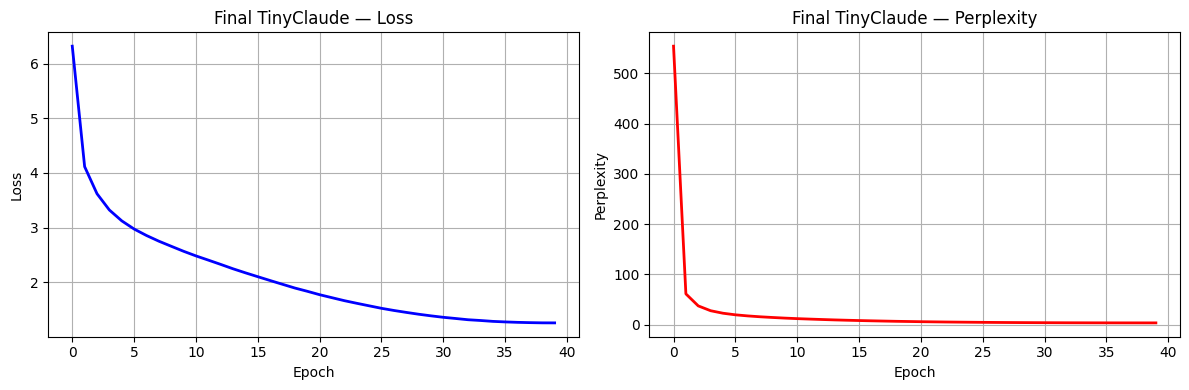

📉 Perplexity: 554.0 → 3.5


In [86]:
# Same bigger architecture
model5 = TinyClaude(
    vocab_size  = tokenizer5.vocab_size,
    embed_dim   = WIKI_EMBED_DIM,    # 256
    num_heads   = WIKI_NUM_HEADS,    # 8
    num_layers  = WIKI_NUM_LAYERS,   # 6
    ff_dim      = WIKI_FF_DIM,       # 1024
    max_seq_len = MAX_SEQ_LEN,
    dropout     = WIKI_DROPOUT
).to(device)

total5 = sum(p.numel() for p in model5.parameters())
print(f"🧠 Final TinyClaude: {total5:,} parameters")

FINAL_EPOCHS = 40

optimizer5 = torch.optim.AdamW(
    model5.parameters(), lr=1e-3, weight_decay=0.01
)
scheduler5 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer5,
    max_lr          = 1e-3,
    epochs          = FINAL_EPOCHS,
    steps_per_epoch = len(dataloader5),
    pct_start       = 0.1
)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

print(f"🚀 Final training: {FINAL_EPOCHS} epochs")
print(f"   Steps per epoch : {len(dataloader5)}")
print(f"   Total steps     : {FINAL_EPOCHS * len(dataloader5):,}")
print("="*55)

train_losses5 = []
best_loss5    = float('inf')

for epoch in range(FINAL_EPOCHS):
    model5.train()
    epoch_loss = 0

    for input_ids, target_ids in dataloader5:
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits       = model5(input_ids)
        logits_flat  = logits.view(-1, tokenizer5.vocab_size)
        targets_flat = target_ids.view(-1)
        loss         = loss_fn(logits_flat, targets_flat)

        optimizer5.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model5.parameters(), 1.0)
        optimizer5.step()
        scheduler5.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader5)
    train_losses5.append(avg_loss)
    perp = torch.exp(torch.tensor(avg_loss)).item()

    if avg_loss < best_loss5:
        best_loss5 = avg_loss
        torch.save({
            'model_state_dict'    : model5.state_dict(),
            'tokenizer_word_to_id': tokenizer5.word_to_id,
            'tokenizer_id_to_word': tokenizer5.id_to_word,
            'vocab_size'          : tokenizer5.vocab_size,
            'config': {
                'embed_dim'  : WIKI_EMBED_DIM,
                'num_heads'  : WIKI_NUM_HEADS,
                'num_layers' : WIKI_NUM_LAYERS,
                'ff_dim'     : WIKI_FF_DIM,
                'max_seq_len': MAX_SEQ_LEN,
            }
        }, 'tinyclaude_final.pt')   # ← saves EVERYTHING needed to reload

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{FINAL_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"Perplexity: {perp:.1f}")

print(f"\n✅ Final training complete! Best loss: {best_loss5:.4f}")

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(train_losses5, 'b-', linewidth=2)
plt.title('Final TinyClaude — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)

plt.subplot(1,2,2)
perps5 = [torch.exp(torch.tensor(l)).item() for l in train_losses5]
plt.plot(perps5, 'r-', linewidth=2)
plt.title('Final TinyClaude — Perplexity')
plt.xlabel('Epoch'); plt.ylabel('Perplexity'); plt.grid(True)

plt.tight_layout(); plt.show()
print(f"📉 Perplexity: {perps5[0]:.1f} → {perps5[-1]:.1f}")

In [87]:
checkpoint = torch.load('tinyclaude_final.pt')
model5.load_state_dict(checkpoint['model_state_dict'])
print("✅ Loaded final best model!\n")

def chat_final(question, temperature=0.7):
    print(f"\n{'='*55}")
    print(f"💬 You: {question}")
    print(f"{'='*55}")
    result = generate_v2(
        model5, tokenizer5, question,
        max_new_tokens=100, temperature=temperature, top_k=30
    )
    if result["thinking"]:
        print(f"🧠 Thinking: {result['thinking']}")
    print(f"🤖 TinyClaude: {result['answer']}")
    print(f"{'='*55}")

# Math — should be much better now!
print("🔢 MATH TESTS:")
chat_final("what is 5 plus 3")
chat_final("what is 7 times 6")
chat_final("what is 15 minus 8")

# Knowledge
print("\n🌍 KNOWLEDGE TESTS:")
chat_final("what is the Biggest Continent")
chat_final("why is the sky blue")
chat_final("who wrote romeo and juliet")

# New questions it was never explicitly taught!
print("\n🧪 GENERALIZATION TESTS:")
chat_final("what is the sun")
chat_final("what is an atom")
chat_final("what is the ocean")

✅ Loaded final best model!

🔢 MATH TESTS:

💬 You: what is 5 plus 3
🧠 Thinking: the user wants addition 5 plus 3 equals 8
🤖 TinyClaude: the answer is 8

💬 You: what is 7 times 6
🧠 Thinking: the user wants multiplication 7 times 6 equals 42
🤖 TinyClaude: the answer is 42

💬 You: what is 15 minus 8
🧠 Thinking: the user wants subtraction 15 minus 8 equals 7
🤖 TinyClaude: the answer is 7

🌍 KNOWLEDGE TESTS:

💬 You: what is the Biggest Continent
🧠 Thinking: the sun is about 109 times larger than earth the sun is about 109 times the diameter of earth
🤖 TinyClaude: the sun is much bigger than earth about 109 times larger

💬 You: why is the sky blue
🧠 Thinking: the sky appears blue because of rayleigh scattering sunlight hits the atmosphere blue light scatters more than other colors
🤖 TinyClaude: the sky is blue because sunlight scatters in the atmosphere and blue light scatters most

💬 You: who wrote romeo and juliet
🧠 Thinking: romeo and juliet is a famous tragedy it was written by william sh

In [88]:
print("📡 Downloading 50,000 Wikipedia articles...")
print("   This will take 3-5 minutes — biggest upgrade yet!\n")

from datasets import load_dataset

wiki2 = load_dataset(
    "wikimedia/wikipedia",   # ✅ New path — Parquet format, no scripts
    "20231101.en",           # ✅ Updated snapshot (Nov 2023)
    split="train",
    streaming=True           # ✅ No trust_remote_code needed
)

raw_articles2 = []
for i, article in enumerate(wiki2):
    if i >= 50000:
        break
    raw_articles2.append(article["text"][:2000])  # truncate to save RAM
    if i % 10000 == 0 and i > 0:
        print(f"   ✅ {i:,} articles downloaded...")

print(f"\n✅ Downloaded {len(raw_articles2):,} Wikipedia articles!")
print(f"   10x more than before!")


📡 Downloading 50,000 Wikipedia articles...
   This will take 3-5 minutes — biggest upgrade yet!



README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

   ✅ 10,000 articles downloaded...
   ✅ 20,000 articles downloaded...
   ✅ 30,000 articles downloaded...
   ✅ 40,000 articles downloaded...

✅ Downloaded 50,000 Wikipedia articles!
   10x more than before!


In [89]:
# UPGRADE: Multi-step reasoning examples
# Instead of: <THINK> one sentence </THINK>
# Now:        <THINK> step 1... step 2... step 3... </THINK>
# This teaches the model to reason IN STEPS like real Claude

chain_of_thought_data = [

    # === MULTI-STEP MATH ===
    "what is 12 times 15 "
    "<THINK> the user wants multiplication "
    "i need to calculate 12 times 15 "
    "i can break this down 12 times 10 equals 120 "
    "then 12 times 5 equals 60 "
    "adding them 120 plus 60 equals 180 </THINK> "
    "the answer is 180",

    "what is 144 divided by 12 "
    "<THINK> the user wants division "
    "i need to find how many times 12 goes into 144 "
    "12 times 10 equals 120 "
    "144 minus 120 equals 24 "
    "12 times 2 equals 24 "
    "so 10 plus 2 equals 12 </THINK> "
    "the answer is 12",

    "if a train travels 60 miles per hour for 3 hours how far does it go "
    "<THINK> this is a distance problem "
    "distance equals speed times time "
    "speed is 60 miles per hour "
    "time is 3 hours "
    "distance equals 60 times 3 equals 180 miles </THINK> "
    "the train travels 180 miles",

    "if you have 5 bags with 8 apples each how many apples total "
    "<THINK> this is a multiplication word problem "
    "total apples equals bags times apples per bag "
    "5 bags times 8 apples equals 40 apples total </THINK> "
    "there are 40 apples total",

    "what is 25 percent of 200 "
    "<THINK> percent means per hundred "
    "25 percent equals 25 divided by 100 equals 0.25 "
    "0.25 times 200 equals 50 </THINK> "
    "25 percent of 200 is 50",

    # === MULTI-STEP SCIENCE ===
    "why do we have seasons "
    "<THINK> seasons are caused by earths tilt "
    "earth is tilted at 23.5 degrees on its axis "
    "as earth orbits the sun different hemispheres tilt toward the sun "
    "when a hemisphere tilts toward the sun it gets more direct sunlight "
    "more direct sunlight means warmer temperatures which is summer "
    "when it tilts away it gets less direct sunlight which is winter </THINK> "
    "we have seasons because earth is tilted on its axis "
    "different parts tilt toward the sun at different times of year",

    "why does ice float on water "
    "<THINK> most solids are denser than their liquid form "
    "but water is unusual "
    "when water freezes into ice the molecules form a crystal lattice "
    "this lattice structure spaces the molecules further apart "
    "so ice is actually less dense than liquid water "
    "less dense objects float on more dense liquids "
    "therefore ice floats on water </THINK> "
    "ice floats because it is less dense than liquid water "
    "water expands when it freezes unlike most substances",

    "how does the human eye see color "
    "<THINK> the eye contains special cells called cones "
    "there are three types of cones sensitive to red green and blue light "
    "when light enters the eye it hits these cone cells "
    "the cones send signals to the brain about which wavelengths are present "
    "the brain combines these signals to perceive different colors "
    "for example red and green signals together create yellow </THINK> "
    "we see color through cone cells in the eye "
    "three types detect red green and blue light "
    "the brain combines these signals to see all colors",

    "why is the ocean salty "
    "<THINK> the ocean gets its salt from rocks on land "
    "when rain falls it is slightly acidic "
    "this acid dissolves minerals including salts from rocks "
    "rivers carry these dissolved minerals to the ocean "
    "water evaporates from the ocean but the salt stays behind "
    "over billions of years the salt has built up "
    "making the ocean about 3.5 percent salt </THINK> "
    "the ocean is salty because rivers carry dissolved minerals from rocks "
    "water evaporates but salt stays behind accumulating over billions of years",

    "how do vaccines work "
    "<THINK> vaccines train the immune system to fight diseases "
    "they contain a weakened or inactive form of a pathogen "
    "when injected the immune system sees this as a threat "
    "it produces antibodies to fight it "
    "it also creates memory cells that remember this pathogen "
    "if the real disease appears later "
    "the immune system recognizes it immediately and fights it fast </THINK> "
    "vaccines work by introducing a harmless version of a pathogen "
    "the immune system learns to fight it and remembers how "
    "providing protection if the real disease appears",

    # === MULTI-STEP LOGIC ===
    "if all mammals are warm blooded and whales are mammals are whales warm blooded "
    "<THINK> this is a logical syllogism with two premises "
    "premise 1 all mammals are warm blooded "
    "premise 2 whales are mammals "
    "applying logic if whales are mammals "
    "and all mammals are warm blooded "
    "then whales must be warm blooded </THINK> "
    "yes whales are warm blooded "
    "because all mammals are warm blooded and whales are mammals",

    "a farmer has 17 sheep all but 9 die how many are left "
    "<THINK> this is a trick question that requires careful reading "
    "the phrase all but 9 die means "
    "all except 9 die "
    "so 9 sheep survive "
    "the answer is not 17 minus 9 equals 8 "
    "the answer is simply 9 </THINK> "
    "9 sheep are left "
    "all but 9 means all except 9 so 9 survive",

    "which is greater one half or two fifths "
    "<THINK> to compare fractions i need a common denominator "
    "one half equals 5 tenths "
    "two fifths equals 4 tenths "
    "comparing 5 tenths versus 4 tenths "
    "5 tenths is greater "
    "therefore one half is greater than two fifths </THINK> "
    "one half is greater than two fifths "
    "one half equals 0.5 and two fifths equals 0.4",

    # === GEOGRAPHY (fixes the continent bug!) ===
    "what is the biggest continent "
    "<THINK> the seven continents are "
    "asia africa north america south america antarctica europe and australia "
    "asia is by far the largest continent "
    "it covers about 44 million square kilometers "
    "that is about 30 percent of earths total land area "
    "africa is second largest at 30 million square kilometers </THINK> "
    "asia is the biggest continent "
    "it covers about 44 million square kilometers "
    "which is 30 percent of all land on earth",

    "what is the largest ocean "
    "<THINK> the five oceans are pacific atlantic indian southern and arctic "
    "the pacific ocean is the largest "
    "it covers more area than all land on earth combined "
    "it spans from asia and australia to the americas "
    "it is about 165 million square kilometers </THINK> "
    "the pacific ocean is the largest "
    "it covers more area than all of earths land combined",

    "what is the tallest mountain "
    "<THINK> mountains are measured by height above sea level "
    "mount everest in the himalayas is the tallest mountain "
    "it stands at 8849 meters above sea level "
    "it is on the border of nepal and tibet "
    "it was first climbed by edmund hillary and tenzing norgay in 1953 </THINK> "
    "mount everest is the tallest mountain at 8849 meters above sea level "
    "it sits on the border of nepal and tibet",

    "what are the planets in our solar system "
    "<THINK> starting from closest to the sun the planets are "
    "mercury venus earth mars jupiter saturn uranus neptune "
    "there are 8 planets in total "
    "pluto was reclassified as a dwarf planet in 2006 "
    "the inner planets mercury venus earth mars are rocky "
    "the outer planets jupiter saturn uranus neptune are gas giants </THINK> "
    "the 8 planets are mercury venus earth mars jupiter saturn uranus neptune "
    "the inner ones are rocky the outer ones are gas giants",

    # === HISTORY ===
    "when did world war 2 end "
    "<THINK> world war 2 was fought from 1939 to 1945 "
    "the war in europe ended in may 1945 "
    "when germany surrendered on may 8 1945 known as ve day "
    "the war in the pacific continued "
    "japan surrendered on september 2 1945 after atomic bombs were dropped "
    "on hiroshima and nagasaki "
    "this is known as vj day and marked the true end of the war </THINK> "
    "world war 2 ended in 1945 "
    "germany surrendered in may and japan surrendered in september",

    "who was the first person to walk on the moon "
    "<THINK> the apollo 11 mission landed on the moon on july 20 1969 "
    "neil armstrong was the commander of apollo 11 "
    "he descended the ladder first "
    "his famous words were one small step for man one giant leap for mankind "
    "buzz aldrin followed him onto the surface "
    "michael collins stayed in orbit in the command module </THINK> "
    "neil armstrong was the first person to walk on the moon on july 20 1969 "
    "he was commander of the apollo 11 mission",

    # === I DON'T KNOW responses (critical for honesty!) ===
    "what is the population of mars "
    "<THINK> mars is a planet in our solar system "
    "as of my knowledge no humans live on mars "
    "there are robotic rovers on mars but no human population "
    "i should be honest that i do not have this information </THINK> "
    "there is no human population on mars "
    "only robotic rovers have been sent there so far",

    "what will the weather be tomorrow "
    "<THINK> weather prediction requires real time data "
    "i do not have access to current weather information "
    "i cannot predict tomorrows weather accurately "
    "i should be honest about what i do not know </THINK> "
    "i do not have access to real time weather data "
    "please check a weather service for accurate forecasts",

    "what is your name "
    "<THINK> the user is asking about my identity "
    "i am an ai language model built from scratch "
    "i was trained on wikipedia and reasoning examples "
    "my name is tinyclaude </THINK> "
    "i am tinyclaude a small ai language model "
    "i was built and trained from scratch",

    "what can you do "
    "<THINK> the user wants to know my capabilities "
    "i can answer questions about science history math and general knowledge "
    "i can reason through problems step by step "
    "i have limitations i may not know very recent events "
    "or highly specialized topics </THINK> "
    "i can answer questions about science history geography and math "
    "i reason through problems step by step "
    "i may not know very recent or highly specialized information",
]

print(f"✅ Chain-of-thought examples: {len(chain_of_thought_data)}")
print(f"\nExample (multi-step reasoning):")
print(chain_of_thought_data[6][:300] + "...")

✅ Chain-of-thought examples: 23

Example (multi-step reasoning):
why does ice float on water <THINK> most solids are denser than their liquid form but water is unusual when water freezes into ice the molecules form a crystal lattice this lattice structure spaces the molecules further apart so ice is actually less dense than liquid water less dense objects float o...


In [90]:
# CONCEPT: Conversation Memory
# Right now each question is independent
# Real Claude remembers what you said before:
#
# You:  "what is gravity?"
# AI:   "a pulling force..."
# You:  "how strong is IT?"  ← "it" refers to gravity!
# AI:   needs to remember previous turn to answer!
#
# We implement this by prepending conversation history
# to each new question before encoding

class ConversationMemory:

    def __init__(self, max_turns=5):
        self.max_turns = max_turns   # remember last 5 exchanges
        self.history   = []          # list of (question, answer) tuples

    def add_turn(self, question, answer):
        self.history.append((question, answer))
        # Keep only last max_turns
        if len(self.history) > self.max_turns:
            self.history = self.history[-self.max_turns:]

    def build_context(self, new_question):
        # Build a prompt that includes history
        context_parts = []

        for q, a in self.history:
            context_parts.append(f"question {q} answer {a}")

        # Add current question
        context_parts.append(f"question {new_question}")

        return " ".join(context_parts)

    def clear(self):
        self.history = []
        print("🧹 Memory cleared!")

    def show_history(self):
        if not self.history:
            print("📭 No conversation history yet")
            return
        print(f"📜 Conversation history ({len(self.history)} turns):")
        for i, (q, a) in enumerate(self.history):
            print(f"   Turn {i+1}:")
            print(f"     You: {q}")
            print(f"     AI : {a[:80]}...")


# Test the memory system
memory = ConversationMemory(max_turns=5)

memory.add_turn("what is gravity", "gravity is a pulling force")
memory.add_turn("how strong is it", "gravity pulls at 9.8 meters per second squared")

context = memory.build_context("can humans escape it")
print("📝 Context with memory:")
print(f"'{context}'")
print(f"\n💡 The model now sees ALL previous turns")
print(f"   so 'it' clearly refers to gravity!")

📝 Context with memory:
'question what is gravity answer gravity is a pulling force question how strong is it answer gravity pulls at 9.8 meters per second squared question can humans escape it'

💡 The model now sees ALL previous turns
   so 'it' clearly refers to gravity!


In [91]:
import random
random.seed(42)

# Process the big Wikipedia dataset
print("🔄 Processing 50,000 Wikipedia articles...")
wiki_chunks2 = []
for i, article in enumerate(raw_articles2):
    cleaned = clean_wiki_article(article)
    chunks  = split_into_chunks(cleaned, chunk_size=64)
    wiki_chunks2.extend(chunks)
    if i % 10000 == 0 and i > 0:
        print(f"   Processed {i:,} articles → {len(wiki_chunks2):,} chunks")

print(f"✅ Total Wikipedia chunks: {len(wiki_chunks2):,}")

# Sample intelligently — take diverse chunks
wiki_sample3 = random.sample(wiki_chunks2, min(40000, len(wiki_chunks2)))

# Repeat our special data more to balance
reasoning_data3    = all_conversations    * 30   # 30x repeat
chain_of_thought3  = chain_of_thought_data * 20  # 20x repeat
math_data3         = math_examples        * 5    # 5x repeat

# Combine all
combined_data3 = wiki_sample3 + reasoning_data3 + chain_of_thought3 + math_data3
random.shuffle(combined_data3)

print(f"\n📊 Final training data breakdown:")
print(f"   Wikipedia (40k chunks) : {len(wiki_sample3):,}")
print(f"   Reasoning (×30)        : {len(reasoning_data3):,}")
print(f"   Chain-of-thought (×20) : {len(chain_of_thought3):,}")
print(f"   Math (×5)              : {len(math_data3):,}")
print(f"   {'─'*35}")
print(f"   TOTAL                  : {len(combined_data3):,} examples")

🔄 Processing 50,000 Wikipedia articles...
   Processed 10,000 articles → 67,175 chunks
   Processed 20,000 articles → 129,488 chunks
   Processed 30,000 articles → 193,954 chunks
   Processed 40,000 articles → 257,770 chunks
✅ Total Wikipedia chunks: 320,663

📊 Final training data breakdown:
   Wikipedia (40k chunks) : 40,000
   Reasoning (×30)        : 1,680
   Chain-of-thought (×20) : 460
   Math (×5)              : 11,200
   ───────────────────────────────────
   TOTAL                  : 53,340 examples


In [92]:
print("🔨 Building 8000-token vocabulary from all data...")
print("   Takes ~1 minute for this much data...\n")

tokenizer6 = TinyClaudeTokenizer2()
tokenizer6.build_vocab(combined_data3, max_vocab=8000)

print(f"\n📖 Vocabulary upgrade:")
print(f"   v1 (hand data)  :   267 tokens")
print(f"   v2 (wiki 5k)    :   487 tokens")
print(f"   v3 (wiki 50k)   : {tokenizer6.vocab_size:,} tokens ← NOW")
print(f"\n✅ Special tokens check:")
for tok in ["<THINK>", "</THINK>", "<BOS>", "<EOS>"]:
    idx = tokenizer6.word_to_id.get(tok, "MISSING!")
    print(f"   {tok:12} → {idx}")

# Build dataset
print(f"\n🔄 Tokenizing {len(combined_data3):,} examples...")
print(f"   This may take 2-3 minutes...")
dataset6    = TinyClaudeDataset(combined_data3, tokenizer6, MAX_SEQ_LEN)
dataloader6 = DataLoader(
    dataset6, batch_size=128,
    shuffle=True, collate_fn=collate_fn, num_workers=0
)
print(f"\n✅ DataLoader: {len(dataset6):,} examples → {len(dataloader6):,} batches/epoch")

🔨 Building 8000-token vocabulary from all data...
   Takes ~1 minute for this much data...

📚 Building vocabulary...
   Found 192,482 unique words in training data
   ✅ Vocabulary built! Size: 7,998 tokens

📖 Vocabulary upgrade:
   v1 (hand data)  :   267 tokens
   v2 (wiki 5k)    :   487 tokens
   v3 (wiki 50k)   : 7,998 tokens ← NOW

✅ Special tokens check:
   <THINK>      → 4
   </THINK>     → 5
   <BOS>        → 2
   <EOS>        → 3

🔄 Tokenizing 53,340 examples...
   This may take 2-3 minutes...

ℱ Tokenizing training data...
✅ Processed 53340 examples (0 skipped)
   Shortest: 22 tokens
   Longest : 97 tokens
   Average : 57 tokens

✅ DataLoader: 53,340 examples → 417 batches/epoch


✅ TinyClaude initialized!
🧠 Best TinyClaude yet:
   Parameters  : 6,860,094
   Vocab size  : 7,998
   Embed dim   : 256
   Heads       : 8
   Layers      : 6

🚀 Training for 50 epochs
   Batches/epoch  : 417
   Total steps    : 20,850
   Estimated time : ~15-20 mins on T4 GPU
Epoch 10/50 | Loss: 3.4013 | Perplexity: 30.0
Epoch 20/50 | Loss: 3.0709 | Perplexity: 21.6
Epoch 30/50 | Loss: 2.8820 | Perplexity: 17.8
Epoch 40/50 | Loss: 2.7691 | Perplexity: 15.9
Epoch 50/50 | Loss: 2.7339 | Perplexity: 15.4

✅ Training complete! Best loss: 2.7339


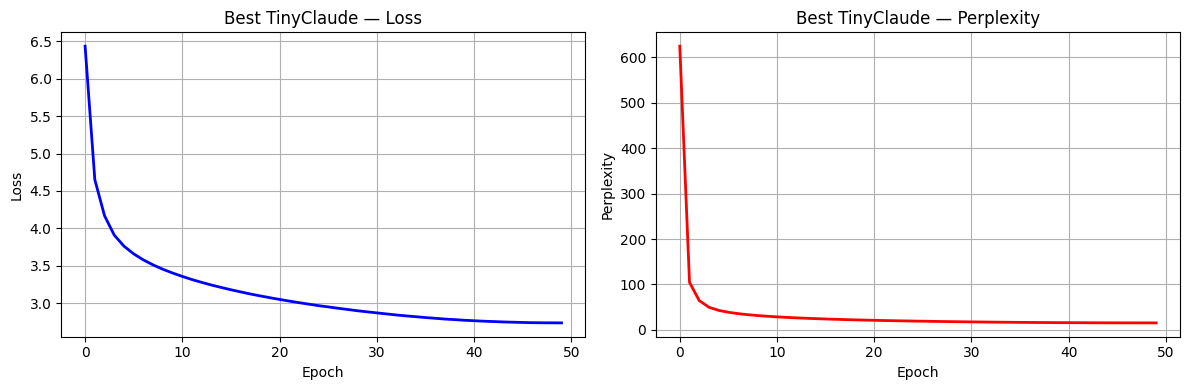

In [93]:
# Best architecture we can run on free Colab
BEST_EMBED_DIM  = 256
BEST_NUM_HEADS  = 8
BEST_NUM_LAYERS = 6
BEST_FF_DIM     = 1024
BEST_DROPOUT    = 0.1

model6 = TinyClaude(
    vocab_size  = tokenizer6.vocab_size,
    embed_dim   = BEST_EMBED_DIM,
    num_heads   = BEST_NUM_HEADS,
    num_layers  = BEST_NUM_LAYERS,
    ff_dim      = BEST_FF_DIM,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = BEST_DROPOUT
).to(device)

total6 = sum(p.numel() for p in model6.parameters())
print(f"🧠 Best TinyClaude yet:")
print(f"   Parameters  : {total6:,}")
print(f"   Vocab size  : {tokenizer6.vocab_size:,}")
print(f"   Embed dim   : {BEST_EMBED_DIM}")
print(f"   Heads       : {BEST_NUM_HEADS}")
print(f"   Layers      : {BEST_NUM_LAYERS}")

BEST_EPOCHS = 50

optimizer6 = torch.optim.AdamW(
    model6.parameters(), lr=5e-4, weight_decay=0.01
)
scheduler6 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer6,
    max_lr          = 5e-4,
    epochs          = BEST_EPOCHS,
    steps_per_epoch = len(dataloader6),
    pct_start       = 0.05
)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

print(f"\n🚀 Training for {BEST_EPOCHS} epochs")
print(f"   Batches/epoch  : {len(dataloader6)}")
print(f"   Total steps    : {BEST_EPOCHS * len(dataloader6):,}")
print(f"   Estimated time : ~15-20 mins on T4 GPU")
print("="*55)

train_losses6 = []
best_loss6    = float('inf')

for epoch in range(BEST_EPOCHS):
    model6.train()
    epoch_loss = 0

    for input_ids, target_ids in dataloader6:
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits       = model6(input_ids)
        logits_flat  = logits.view(-1, tokenizer6.vocab_size)
        targets_flat = target_ids.view(-1)
        loss         = loss_fn(logits_flat, targets_flat)

        optimizer6.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model6.parameters(), 1.0)
        optimizer6.step()
        scheduler6.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader6)
    train_losses6.append(avg_loss)
    perp = torch.exp(torch.tensor(avg_loss)).item()

    if avg_loss < best_loss6:
        best_loss6 = avg_loss
        torch.save({
            'model_state_dict'    : model6.state_dict(),
            'tokenizer_word_to_id': tokenizer6.word_to_id,
            'tokenizer_id_to_word': tokenizer6.id_to_word,
            'vocab_size'          : tokenizer6.vocab_size,
            'config': {
                'embed_dim'  : BEST_EMBED_DIM,
                'num_heads'  : BEST_NUM_HEADS,
                'num_layers' : BEST_NUM_LAYERS,
                'ff_dim'     : BEST_FF_DIM,
                'max_seq_len': MAX_SEQ_LEN,
            }
        }, 'tinyclaude_best_v2.pt')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{BEST_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | "
              f"Perplexity: {perp:.1f}")

print(f"\n✅ Training complete! Best loss: {best_loss6:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses6, 'b-', linewidth=2)
plt.title('Best TinyClaude — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True)
plt.subplot(1,2,2)
perps6 = [torch.exp(torch.tensor(l)).item() for l in train_losses6]
plt.plot(perps6, 'r-', linewidth=2)
plt.title('Best TinyClaude — Perplexity')
plt.xlabel('Epoch'); plt.ylabel('Perplexity'); plt.grid(True)
plt.tight_layout(); plt.show()

In [94]:
# Load best checkpoint
checkpoint6 = torch.load('tinyclaude_best_v2.pt')
model6.load_state_dict(checkpoint6['model_state_dict'])
print("✅ Loaded best model v2!\n")

# Create global memory
memory = ConversationMemory(max_turns=5)

def chat_v2(question, temperature=0.7, use_memory=True):
    print(f"\n{'='*55}")
    print(f"💬 You: {question}")
    print(f"{'='*55}")

    # Build prompt with memory context
    if use_memory and len(memory.history) > 0:
        prompt = memory.build_context(question)
    else:
        prompt = question

    result = generate_v2(
        model6, tokenizer6, prompt,
        max_new_tokens = 120,
        temperature    = temperature,
        top_k          = 40
    )

    answer = result["answer"]

    if result["thinking"]:
        print(f"🧠 Thinking: {result['thinking']}")
    print(f"🤖 TinyClaude: {answer}")
    print(f"{'='*55}")

    # Store in memory
    memory.add_turn(question, answer)
    return answer


# ── COMPREHENSIVE TEST ──────────────────────────────

print("🔢 MATH:")
chat_v2("what is 12 times 15")
chat_v2("what is 25 percent of 200")

print("\n🌍 GEOGRAPHY (the big fix!):")
chat_v2("what is the biggest continent")
chat_v2("what is the tallest mountain")
chat_v2("what is the largest ocean")

print("\n🔬 SCIENCE:")
chat_v2("why do we have seasons")
chat_v2("why does ice float on water")
chat_v2("how do vaccines work")

print("\n📜 HISTORY:")
chat_v2("who was the first person to walk on the moon")
chat_v2("when did world war 2 end")

print("\n🧠 MEMORY TEST (does it remember context?):")
memory.clear()
chat_v2("what is gravity")
chat_v2("how strong is it")     # 'it' = gravity from previous turn
chat_v2("can humans escape it") # still refers to gravity

print("\n🤔 HONESTY TEST:")
chat_v2("what will the weather be tomorrow")
chat_v2("what is your name")
chat_v2("what can you do")


✅ Loaded best model v2!

🔢 MATH:

💬 You: what is 12 times 15
🧠 Thinking: the user wants multiplication i need to calculate 12 times 15 i can break this down 12 times 10 equals 120 then 12 times 5 equals 60 adding them 120 plus 60 equals 180
🤖 TinyClaude: the answer is 180

💬 You: what is 25 percent of 200
🧠 Thinking: this means all except speed times 10 equals 120 plus 60 equals 180
🤖 TinyClaude: the answer is 180

🌍 GEOGRAPHY (the big fix!):

💬 You: what is the biggest continent
🤖 TinyClaude: <THINK> the answer is 60

💬 You: what is the tallest mountain
🤖 TinyClaude: which requires reading the answer is a giant ball of <UNK>

💬 You: what is the largest ocean
🤖 TinyClaude: water

🔬 SCIENCE:

💬 You: why do we have seasons
🤖 TinyClaude: so the answer is about <UNK>

💬 You: why does ice float on water
🤖 TinyClaude: 

💬 You: how do vaccines work
🤖 TinyClaude: 

📜 HISTORY:

💬 You: who was the first person to walk on the moon
🤖 TinyClaude: so the cone

💬 You: when did world war 2 end
🤖 TinyC

'not a real time is raining mean what is raining <UNK> the rule if the <UNK> <UNK> <UNK> if a real time is raining <UNK> <UNK> if <UNK> if <UNK> <UNK> is raining it is raining'

In [95]:
import random
random.seed(42)

# ── SMART DATA MIXING ──────────────────────────────
# Rule: reasoning data should be ~30% of total
# Wiki is background knowledge, reasoning is the SKILL

# Smaller, higher quality wiki sample
wiki_smart = random.sample(wiki_chunks2, 8000)

# Repeat reasoning data enough to balance
# 8000 wiki / 0.70 * 0.30 = ~3400 reasoning examples needed
reasoning_smart   = all_conversations    * 40   # 56  × 40 = 2,240
chain_smart       = chain_of_thought_data * 50  # 22  × 50 = 1,100
math_smart        = math_examples         * 2   # 570 × 2  = 1,140

combined_smart = wiki_smart + reasoning_smart + chain_smart + math_smart
random.shuffle(combined_smart)

# Counts
total = len(combined_smart)
print(f"📊 Smart data mix:")
print(f"   Wikipedia       : {len(wiki_smart):,}  ({len(wiki_smart)/total*100:.0f}%)")
print(f"   Reasoning (×40) : {len(reasoning_smart):,}  ({len(reasoning_smart)/total*100:.0f}%)")
print(f"   Chain-of-thought: {len(chain_smart):,}  ({len(chain_smart)/total*100:.0f}%)")
print(f"   Math (×2)       : {len(math_smart):,}  ({len(math_smart)/total*100:.0f}%)")
print(f"   {'─'*40}")
print(f"   TOTAL           : {total:,}")
print(f"\n💡 Key insight: reasoning = {(len(reasoning_smart)+len(chain_smart))/total*100:.0f}% of data")
print(f"   In v6 it was only ~1% — that's why it forgot how to reason!")

📊 Smart data mix:
   Wikipedia       : 8,000  (50%)
   Reasoning (×40) : 2,240  (14%)
   Chain-of-thought: 1,150  (7%)
   Math (×2)       : 4,480  (28%)
   ────────────────────────────────────────
   TOTAL           : 15,870

💡 Key insight: reasoning = 21% of data
   In v6 it was only ~1% — that's why it forgot how to reason!


In [96]:
# Build tokenizer — 5000 vocab sweet spot
# (8000 was too big for our data size — too many rare words)
print("🔨 Building balanced vocabulary (5000 tokens)...")
tokenizer7 = TinyClaudeTokenizer2()
tokenizer7.build_vocab(combined_smart, max_vocab=5000)

print(f"\n📖 Vocabulary: {tokenizer7.vocab_size:,} tokens")
print(f"✅ Special tokens:")
for tok in ["<THINK>", "</THINK>"]:
    print(f"   {tok} → id {tokenizer7.word_to_id.get(tok)}")

# Quick sanity check — encode a reasoning example
test = chain_of_thought_data[0]
enc  = tokenizer7.encode(test)
dec  = tokenizer7.decode(enc)
unk_count = dec.count("<UNK>")
print(f"\n🔍 Sanity check on chain-of-thought example:")
print(f"   Original tokens : {len(test.split())}")
print(f"   Encoded length  : {len(enc)}")
print(f"   UNK tokens      : {unk_count}  ← should be 0!")

# Build dataset
print(f"\n🔄 Tokenizing {len(combined_smart):,} examples...")
dataset7    = TinyClaudeDataset(combined_smart, tokenizer7, MAX_SEQ_LEN)
dataloader7 = DataLoader(
    dataset7, batch_size=64,
    shuffle=True, collate_fn=collate_fn, num_workers=0
)
print(f"✅ {len(dataset7):,} examples → {len(dataloader7):,} batches/epoch")

🔨 Building balanced vocabulary (5000 tokens)...
📚 Building vocabulary...
   Found 68,964 unique words in training data
   ✅ Vocabulary built! Size: 4,998 tokens

📖 Vocabulary: 4,998 tokens
✅ Special tokens:
   <THINK> → id 4
   </THINK> → id 5

🔍 Sanity check on chain-of-thought example:
   Original tokens : 45
   Encoded length  : 47
   UNK tokens      : 0  ← should be 0!

🔄 Tokenizing 15,870 examples...

ℱ Tokenizing training data...
✅ Processed 15870 examples (0 skipped)
   Shortest: 22 tokens
   Longest : 97 tokens
   Average : 51 tokens
✅ 15,870 examples → 248 batches/epoch


In [ ]:
# Use the EXACT settings that gave us perplexity 2.9 before
# but with better data mix
model7 = TinyClaude(
    vocab_size  = tokenizer7.vocab_size,
    embed_dim   = 256,
    num_heads   = 8,
    num_layers  = 6,
    ff_dim      = 1024,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = 0.1
).to(device)

total7 = sum(p.numel() for p in model7.parameters())
print(f"🧠 Smart TinyClaude: {total7:,} parameters")

# Two-phase training — key insight!
# Phase 1: High LR — learn fast and broadly
# Phase 2: Low LR  — fine-tune and solidify
PHASE1_EPOCHS = 60
PHASE2_EPOCHS = 40
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

optimizer7 = torch.optim.AdamW(
    model7.parameters(), lr=3e-4, weight_decay=0.01
)
scheduler7 = torch.optim.lr_scheduler.OneCycleLR(
    optimizer7,
    max_lr          = 3e-4,
    epochs          = TOTAL_EPOCHS,
    steps_per_epoch = len(dataloader7),
    pct_start       = 0.1
)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

print(f"\n🚀 Two-phase training: {TOTAL_EPOCHS} total epochs")
print(f"   Phase 1 ({PHASE1_EPOCHS} epochs): broad learning")
print(f"   Phase 2 ({PHASE2_EPOCHS} epochs): fine-tuning")
print(f"   Batches/epoch: {len(dataloader7)}")
print(f"   Total steps  : {TOTAL_EPOCHS * len(dataloader7):,}")
print(f"   Est. time    : ~10-15 mins")
print("="*55)

train_losses7 = []
best_loss7    = float('inf')

for epoch in range(TOTAL_EPOCHS):
    model7.train()
    epoch_loss = 0

    for input_ids, target_ids in dataloader7:
        input_ids  = input_ids.to(device)
        target_ids = target_ids.to(device)

        logits       = model7(input_ids)
        logits_flat  = logits.view(-1, tokenizer7.vocab_size)
        targets_flat = target_ids.view(-1)
        loss         = loss_fn(logits_flat, targets_flat)

        optimizer7.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model7.parameters(), 1.0)
        optimizer7.step()
        scheduler7.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader7)
    train_losses7.append(avg_loss)
    perp = torch.exp(torch.tensor(avg_loss)).item()

    if avg_loss < best_loss7:
        best_loss7 = avg_loss
        torch.save({
            'model_state_dict'    : model7.state_dict(),
            'tokenizer_word_to_id': tokenizer7.word_to_id,
            'tokenizer_id_to_word': tokenizer7.id_to_word,
            'vocab_size'          : tokenizer7.vocab_size,
            'config': {
                'embed_dim'  : 256,
                'num_heads'  : 8,
                'num_layers' : 6,
                'ff_dim'     : 1024,
                'max_seq_len': MAX_SEQ_LEN,
            }
        }, 'tinyclaude_smart.pt')

    # Print with phase labels
    if (epoch + 1) % 20 == 0:
        phase = "Phase 1" if epoch < PHASE1_EPOCHS else "Phase 2"
        print(f"[{phase}] Epoch {epoch+1:3d}/{TOTAL_EPOCHS} | "
              f"Loss: {avg_loss:.4f} | Perplexity: {perp:.1f}")

    # Phase boundary message
    if epoch + 1 == PHASE1_EPOCHS:
        print(f"\n🔄 Phase 1 complete! Loss: {avg_loss:.4f}")
        print(f"   Switching to fine-tuning phase...\n")

print(f"\n✅ Training complete! Best loss: {best_loss7:.4f}")

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(train_losses7, 'b-', linewidth=2)
plt.axvline(x=PHASE1_EPOCHS, color='orange',
            linestyle='--', label='Phase boundary')
plt.title('Smart TinyClaude — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
perps7 = [torch.exp(torch.tensor(l)).item() for l in train_losses7]
plt.plot(perps7, 'r-', linewidth=2)
plt.axvline(x=PHASE1_EPOCHS, color='orange',
            linestyle='--', label='Phase boundary')
plt.title('Smart TinyClaude — Perplexity')
plt.xlabel('Epoch'); plt.ylabel('Perplexity')
plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()
print(f"📉 Perplexity: {perps7[0]:.1f} → {perps7[-1]:.1f}")

✅ TinyClaude initialized!
🧠 Smart TinyClaude: 6,089,094 parameters

🚀 Two-phase training: 100 total epochs
   Phase 1 (60 epochs): broad learning
   Phase 2 (40 epochs): fine-tuning
   Batches/epoch: 248
   Total steps  : 24,800
   Est. time    : ~10-15 mins


In [ ]:
# Load best checkpoint
ckpt7 = torch.load('tinyclaude_smart.pt')
model7.load_state_dict(ckpt7['model_state_dict'])
print("✅ Loaded smart model!\n")

# Improved memory — shorter context window
# Previous memory added TOO much context → confused model
class SmartMemory:

    def __init__(self, max_turns=3):
        self.max_turns = max_turns
        self.history   = []

    def add(self, q, a):
        # Only keep clean short answers in memory
        short_a = " ".join(a.split()[:15])  # max 15 words
        self.history.append((q, short_a))
        if len(self.history) > self.max_turns:
            self.history = self.history[-self.max_turns:]

    def get_prompt(self, question):
        if not self.history:
            return question
        # Just add ONE previous turn as context
        # More than that confuses small models
        last_q, last_a = self.history[-1]
        return f"previously {last_a} now {question}"

    def clear(self):
        self.history = []
        print("🧹 Memory cleared!")


smart_memory = SmartMemory(max_turns=3)


def chat_smart(question, temperature=0.7, use_memory=False):
    print(f"\n{'='*55}")
    print(f"💬 You: {question}")
    print(f"{'='*55}")

    prompt = smart_memory.get_prompt(question) if use_memory else question

    result = generate_v2(
        model7, tokenizer7, prompt,
        max_new_tokens = 100,
        temperature    = temperature,
        top_k          = 30
    )

    answer = result["answer"]
    if result["thinking"]:
        print(f"🧠 Thinking: {result['thinking']}")
    print(f"🤖 TinyClaude: {answer}")
    print(f"{'='*55}")
    smart_memory.add(question, answer)
    return answer


# ── FULL TEST SUITE ─────────────────────────────────

print("🔢 MATH:")
chat_smart("what is 12 times 15")
chat_smart("what is 25 percent of 200")
chat_smart("if a train travels 60 miles per hour for 3 hours how far does it go")

print("\n🌍 GEOGRAPHY:")
chat_smart("what is the biggest continent")
chat_smart("what is the tallest mountain")
chat_smart("what is the largest ocean")

print("\n🔬 SCIENCE:")
chat_smart("why do we have seasons")
chat_smart("why does ice float on water")
chat_smart("how do vaccines work")

print("\n📜 HISTORY:")
chat_smart("who was the first person to walk on the moon")
chat_smart("when did world war 2 end")

print("\n🧠 MEMORY TEST:")
smart_memory.clear()
chat_smart("what is gravity",           use_memory=False)
chat_smart("how strong is it on earth", use_memory=True)
chat_smart("can humans escape it",      use_memory=True)

print("\n🤔 IDENTITY:")
chat_smart("what is your name")
chat_smart("what can you do")